<a href="https://colab.research.google.com/github/GUIVICFISHER/RiskNeutralKernel2026/blob/main/STOCK_ANALYZER_EXP_1_ALPACA_CONNECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### New Graphical Analysis: Macroeconomic Indicators (CPI and GDP Trends)

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure cpi_data and gdp_data are loaded and indexed as datetime
# (Assuming cpi_data and gdp_data are available from previous executions, e.g., cell 5bfc0193)
cpi_data.index = pd.to_datetime(cpi_data.index)
gdp_data.index = pd.to_datetime(gdp_data.index)

# Plotting CPI over time
plt.figure(figsize=(15, 7))
plt.plot(cpi_data.index, cpi_data['CPI'], label='Consumer Price Index (CPI)', color='blue')
plt.title('Historical Consumer Price Index (CPI) Over Time')
plt.xlabel('Date')
plt.ylabel('CPI Value')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

# Plotting GDP over time
plt.figure(figsize=(15, 7))
plt.plot(gdp_data.index, gdp_data['GDP'], label='Gross Domestic Product (GDP)', color='green')
plt.title('Historical Gross Domestic Product (GDP) Over Time')
plt.xlabel('Date')
plt.ylabel('GDP Value')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

NameError: name 'cpi_data' is not defined

In [2]:
# Calculate the year-over-year percentage change for CPI (inflation rate)
cpi_growth_rate = cpi_data['CPI'].pct_change(periods=12).dropna() * 100 # Annual inflation rate

# Calculate the quarter-over-quarter annualized percentage change for GDP (GDP growth rate)
# GDP is typically quarterly, so we use periods=1 for quarter-over-quarter, then annualize
gdp_growth_rate = gdp_data['GDP'].pct_change(periods=1).dropna() * 4 * 100 # Annualized quarterly growth

# Plotting CPI Growth Rate (Inflation)
plt.figure(figsize=(15, 7))
plt.plot(cpi_growth_rate.index, cpi_growth_rate, label='CPI Inflation Rate (Year-over-Year % Change)', color='purple')
plt.title('Historical CPI Inflation Rate')
plt.xlabel('Date')
plt.ylabel('Inflation Rate (%)')
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

# Plotting GDP Growth Rate
plt.figure(figsize=(15, 7))
plt.plot(gdp_growth_rate.index, gdp_growth_rate, label='GDP Growth Rate (Annualized Quarterly % Change)', color='orange')
plt.title('Historical GDP Growth Rate')
plt.xlabel('Date')
plt.ylabel('GDP Growth Rate (%)')
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

NameError: name 'cpi_data' is not defined

### Explanation of New Macroeconomic Plots

These newly generated graphs provide a direct visualization of the core macroeconomic indicators: the Consumer Price Index (CPI) and Gross Domestic Product (GDP).

1.  **Historical Consumer Price Index (CPI) Over Time:**
    *   This plot shows the raw CPI values over the entire available history. CPI is a measure of the average change over time in the prices paid by urban consumers for a market basket of consumer goods and services. Observing its trend gives us a direct view of the general price level in the economy.

2.  **Historical Gross Domestic Product (GDP) Over Time:**
    *   This plot displays the raw GDP values. GDP represents the total monetary or market value of all the finished goods and services produced within a country's borders in a specific time period. Its trend indicates the overall economic output and health of the nation.

3.  **Historical CPI Inflation Rate (Year-over-Year % Change):**
    *   Instead of raw CPI values, this graph shows the *rate of change* in CPI, typically referred to as the inflation rate. A year-over-year percentage change helps to smooth out seasonal variations and provides a clear picture of how quickly prices are rising or falling annually. This is a critical factor for understanding the purchasing power of currency and its potential impact on commodity values.

4.  **Historical GDP Growth Rate (Annualized Quarterly % Change):**
    *   This plot illustrates the *rate of change* in GDP, known as the economic growth rate. For quarterly data, it's common to annualize the quarter-over-quarter growth to represent what the growth would be if it continued for a full year. Positive growth indicates economic expansion, while negative growth signifies contraction (recession). Economic growth directly influences demand for commodities and overall market sentiment.

By analyzing these trends, we can better understand the broader economic forces that may be driving the prices and relationships of assets like oil and gold, as explored in previous analyses.

### Expanding Macroeconomic Environment Analysis: Key Economic Indicators

To build a more complete picture of the macroeconomic environment affecting commodity markets, we will now fetch and visualize additional critical indicators. These include:

*   **Producer Price Index (PPI):** Measures the average change over time in the selling prices received by domestic producers for their output.
*   **Unemployment Rate:** A key indicator of labor market health and overall economic activity.
*   **Federal Funds Effective Rate (Interest Rates):** Reflects the central bank's monetary policy stance.
*   **ISM Manufacturing PMI:** An indicator of the economic health of the manufacturing sector.
*   **Consumer Confidence Index (CCI):** Gauges consumer sentiment about current economic conditions and future expectations.
*   **S&P/Case-Shiller U.S. National Home Price Index:** Provides a broad measure of the value of residential housing in the U.S.

In [13]:
import pandas_datareader as pdr
import datetime
import matplotlib.pyplot as plt

# Define the start and end dates for fetching data, consistent with previous analyses
start_date = datetime.datetime(2000, 1, 1)
end_date = datetime.datetime.now()

print("Fetching additional historical macroeconomic data from FRED...")

# Fetch Producer Price Index (PPI) - Final Demand
ppi_data = pdr.get_data_fred('PPIFGS', start=start_date, end=end_date)
ppi_data.rename(columns={'PPIFGS': 'PPI'}, inplace=True)

# Fetch Unemployment Rate
unemp_data = pdr.get_data_fred('UNRATE', start=start_date, end=end_date)
unemp_data.rename(columns={'UNRATE': 'Unemployment_Rate'}, inplace=True)

# Fetch Federal Funds Effective Rate (Interest Rates)
fed_funds_data = pdr.get_data_fred('FEDFUNDS', start=start_date, end=end_date)
fed_funds_data.rename(columns={'FEDFUNDS': 'Fed_Funds_Rate'}, inplace=True)

# ISM Manufacturing PMI data fetch has been temporarily removed due to persistent RemoteDataError.
# We will proceed with other indicators.
# pmi_data_fred = pdr.get_data_fred('NAPMPMI', start=start_date, end=end_date)
# pmi_data_fred.rename(columns={'NAPMPMI': 'ISM_PMI'}, inplace=True)

# Fetch Consumer Confidence Index (CCI) from FRED (might be different data series depending on source)
# Using 'UMCSENT' for University of Michigan: Consumer Sentiment
ccu_data = pdr.get_data_fred('UMCSENT', start=start_date, end=end_date)
ccu_data.rename(columns={'UMCSENT': 'Consumer_Confidence'}, inplace=True)

# Fetch S&P/Case-Shiller U.S. National Home Price Index
hpi_data = pdr.get_data_fred('CSUSHPINSA', start=start_date, end=end_date)
hpi_data.rename(columns={'CSUSHPINSA': 'Home_Price_Index'}, inplace=True)

print("PPI Data Head:")
display(ppi_data.head())

print("\nUnemployment Data Head:")
display(unemp_data.head())

print("\nFederal Funds Rate Data Head:")
display(fed_funds_data.head())

# print("\nISM PMI Data Head:")
# display(pmi_data_fred.head())

print("\nConsumer Confidence Data Head:")
display(ccu_data.head())

print("\nHome Price Index Data Head:")
display(hpi_data.head())

Fetching additional historical macroeconomic data from FRED...
PPI Data Head:


,PPI
DATE,
2000-01-01,135.2
2000-02-01,136.6
2000-03-01,137.3
2000-04-01,136.9
2000-05-01,137.0



Unemployment Data Head:


,Unemployment_Rate
DATE,
2000-01-01,4.0
2000-02-01,4.1
2000-03-01,4.0
2000-04-01,3.8
2000-05-01,4.0



Federal Funds Rate Data Head:


,Fed_Funds_Rate
DATE,
2000-01-01,5.45
2000-02-01,5.73
2000-03-01,5.85
2000-04-01,6.02
2000-05-01,6.27



Consumer Confidence Data Head:


,Consumer_Confidence
DATE,
2000-01-01,112.0
2000-02-01,111.3
2000-03-01,107.1
2000-04-01,109.2
2000-05-01,110.7



Home Price Index Data Head:


,Home_Price_Index
DATE,
2000-01-01,100.000
2000-02-01,100.571
2000-03-01,101.466
2000-04-01,102.540
2000-05-01,103.701


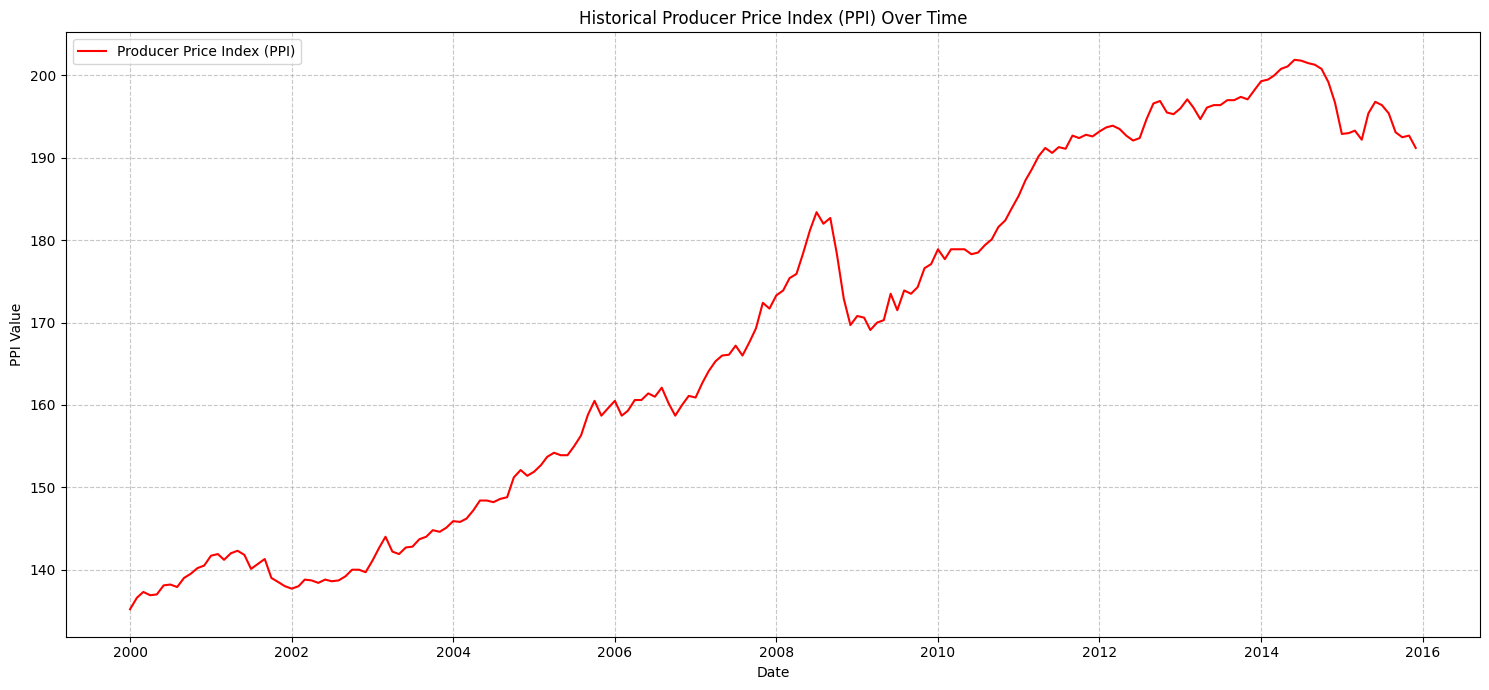

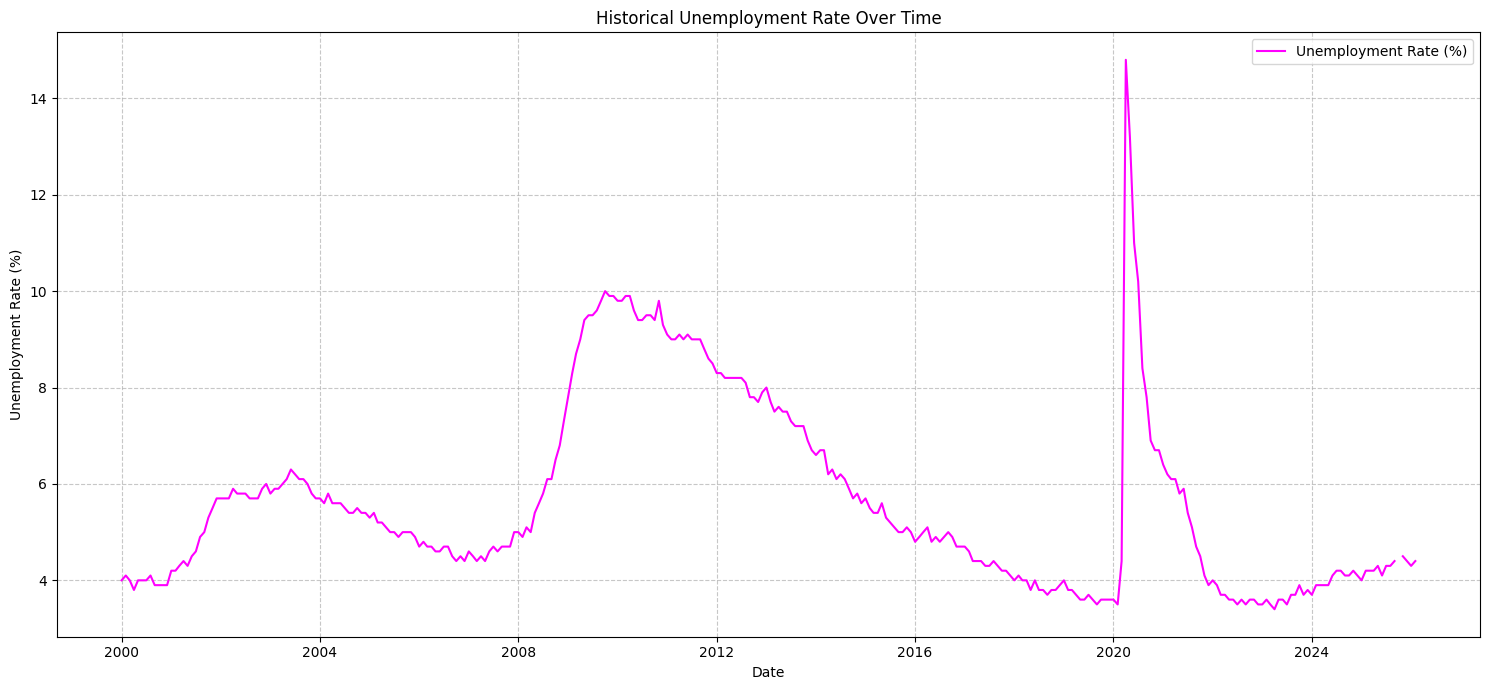

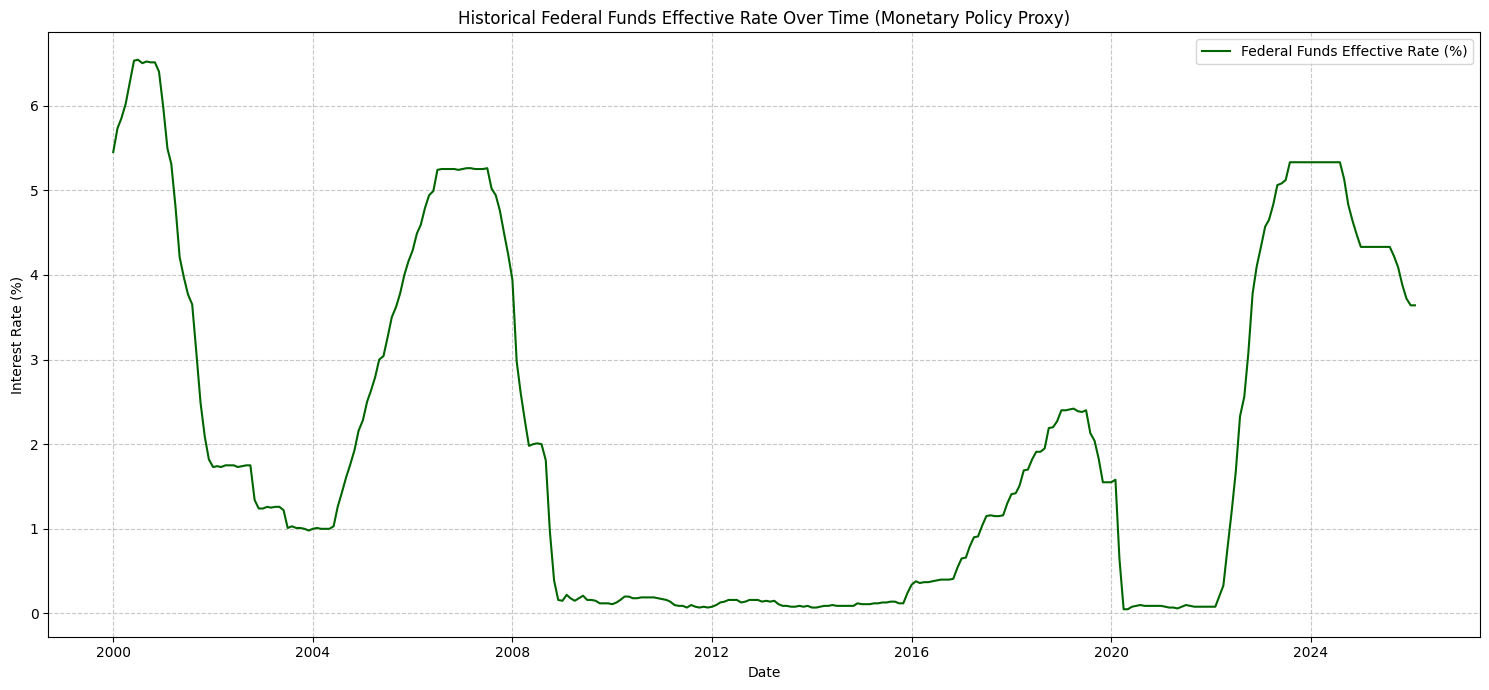

NameError: name 'pmi_data_fred' is not defined

<Figure size 1500x700 with 0 Axes>

In [4]:
import pandas_datareader as pdr
import datetime
import matplotlib.pyplot as plt

# Plotting PPI over time
plt.figure(figsize=(15, 7))
plt.plot(ppi_data.index, ppi_data['PPI'], label='Producer Price Index (PPI)', color='red')
plt.title('Historical Producer Price Index (PPI) Over Time')
plt.xlabel('Date')
plt.ylabel('PPI Value')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

# Plotting Unemployment Rate over time
plt.figure(figsize=(15, 7))
plt.plot(unemp_data.index, unemp_data['Unemployment_Rate'], label='Unemployment Rate (%)', color='magenta')
plt.title('Historical Unemployment Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

# Plotting Federal Funds Effective Rate over time
plt.figure(figsize=(15, 7))
plt.plot(fed_funds_data.index, fed_funds_data['Fed_Funds_Rate'], label='Federal Funds Effective Rate (%)', color='darkgreen')
plt.title('Historical Federal Funds Effective Rate Over Time (Monetary Policy Proxy)')
plt.xlabel('Date')
plt.ylabel('Interest Rate (%)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

# Plotting ISM Manufacturing PMI over time
# Temporarily commented out as pmi_data_fred is not consistently available.
# plt.figure(figsize=(15, 7))
# plt.plot(pmi_data_fred.index, pmi_data_fred['ISM_PMI'], label='ISM Manufacturing PMI', color='cyan')
# plt.title('Historical ISM Manufacturing PMI Over Time')
# plt.xlabel('Date')
# plt.ylabel('PMI Index Value')
# plt.axhline(50, color='gray', linestyle='--', linewidth=0.8, label='50 (Expansion/Contraction Threshold)') # 50 is the threshold
# plt.grid(True, linestyle='--', alpha=0.7)
# plt.legend()
# plt.tight_layout()
# plt.show()

# Plotting Consumer Confidence Index over time
plt.figure(figsize=(15, 7))
plt.plot(ccu_data.index, ccu_data['Consumer_Confidence'], label='Consumer Confidence Index', color='navy')
plt.title('Historical Consumer Confidence Index Over Time')
plt.xlabel('Date')
plt.ylabel('Index Value')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

# Plotting S&P/Case-Shiller U.S. National Home Price Index over time
plt.figure(figsize=(15, 7))
plt.plot(hpi_data.index, hpi_data['Home_Price_Index'], label='S&P/Case-Shiller Home Price Index', color='orange')
plt.title('Historical S&P/Case-Shiller U.S. National Home Price Index Over Time')
plt.xlabel('Date')
plt.ylabel('Index Value')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

### Explanation of Additional Macroeconomic Plots

These plots provide a deeper dive into various facets of the macroeconomic environment:

1.  **Historical Producer Price Index (PPI) Over Time:** The PPI tracks the average change in selling prices received by domestic producers for their output. It's often seen as a leading indicator of consumer price inflation (CPI), as increases in producer costs can eventually be passed on to consumers.

2.  **Historical Unemployment Rate Over Time:** A low and stable unemployment rate generally indicates a healthy economy, as more people are employed and contributing to economic output. High unemployment can signal economic contraction and reduced consumer spending.

3.  **Historical Federal Funds Effective Rate Over Time:** This is a crucial interest rate controlled by the Federal Reserve (or central banks globally), influencing other interest rates throughout the economy. It reflects the central bank's monetary policy decisions to either stimulate (lower rates) or cool down (raise rates) economic activity, directly impacting borrowing costs for businesses and consumers.

4.  **Historical ISM Manufacturing PMI Over Time:** The Purchasing Managers' Index (PMI) for manufacturing measures the health of the manufacturing sector. A reading above 50 generally indicates expansion, while a reading below 50 suggests contraction. This provides insight into industrial activity and future economic growth.

5.  **Historical Consumer Confidence Index Over Time:** This index measures consumers' optimism about the state of the economy. High consumer confidence often translates to increased spending, which drives economic growth, while low confidence can lead to reduced spending and economic slowdowns.

6.  **Historical S&P/Case-Shiller U.S. National Home Price Index Over Time:** Housing prices are a significant component of household wealth and a barometer for the overall economy. Trends in home prices can reflect economic stability, inflationary pressures, and consumer financial health.

By monitoring these indicators, we gain a more nuanced understanding of the economic forces that can influence investment decisions and commodity prices, complementing our previous analysis of CPI and GDP.

### Enhanced Technical Analysis: Advanced Indicators

Moving beyond basic price charts and correlations, we delve into more advanced technical indicators to uncover potential trading signals and market momentum. This section will introduce:

*   **Moving Average Convergence Divergence (MACD):** A trend-following momentum indicator that shows the relationship between two moving averages of a security’s price.
*   **Stochastic Oscillator:** A momentum indicator comparing a particular closing price of a security to a range of its prices over a certain period of time.
*   **Volume Analysis:** Visualizing trading volume alongside price provides context to price movements, indicating the strength of a trend.

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf # Added missing import

# Ensure combined_data is available from previous cells (e.g., abc14c11) and has 'Oil_Close', 'Gold_Close' columns

oil_ticker = 'CL=F'
gold_ticker = 'GC=F'

# --- Calculate MACD ---
# MACD Line: (12-day EMA - 26-day EMA)
# Signal Line: 9-day EMA of MACD Line
# Histogram: MACD Line - Signal Line

def calculate_macd(series, fast_period=12, slow_period=26, signal_period=9):
    exp1 = series.ewm(span=fast_period, adjust=False).mean()
    exp2 = series.ewm(span=slow_period, adjust=False).mean()
    macd_line = exp1 - exp2
    signal_line = macd_line.ewm(span=signal_period, adjust=False).mean()
    macd_histogram = macd_line - signal_line
    return macd_line, signal_line, macd_histogram

oil_macd_line, oil_signal_line, oil_macd_histogram = calculate_macd(combined_data['Oil_Close'])
gold_macd_line, gold_signal_line, gold_macd_histogram = calculate_macd(combined_data['Gold_Close'])

# --- Calculate Stochastic Oscillator ---
# %K = ((Current Close - Lowest Low) / (Highest High - Lowest Low)) * 100
# %D = 3-day SMA of %K

def calculate_stochastic_oscillator(df, period=14, smooth_k=3, smooth_d=3):
    low_min = df['Low'].rolling(window=period).min()
    high_max = df['High'].rolling(window=period).max()
    K = ((df['Close'] - low_min) / (high_max - low_min)) * 100
    D = K.rolling(window=smooth_d).mean()
    return K, D

# For Stochastic Oscillator, we need High, Low, Close data.
# Re-fetch full data if only 'Close' was stored in combined_data
# Or assume that the full yf.download results for 'oil_data' and 'gold_data' are available.
# For consistency, I will re-download a minimal set to get High/Low/Close if combined_data only has 'Close'

oil_full_data = yf.download(oil_ticker, period='max')
gold_full_data = yf.download(gold_ticker, period='max')

# Merge High/Low/Close for stochastic calculation
oil_stoch_df = oil_full_data[['High', 'Low', 'Close']].dropna()
gold_stoch_df = gold_full_data[['High', 'Low', 'Close']].dropna()

oil_k, oil_d = calculate_stochastic_oscillator(oil_stoch_df)
gold_k, gold_d = calculate_stochastic_oscillator(gold_stoch_df)

# --- Plotting Technical Indicators in a Grid ---

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(20, 20), sharex='col')
fig.suptitle('Advanced Technical Analysis: MACD, Stochastic Oscillator, and Volume', fontsize=16)

# Plot Oil MACD
axes[0, 0].plot(oil_macd_line.index, oil_macd_line, label='MACD Line', color='blue')
axes[0, 0].plot(oil_signal_line.index, oil_signal_line, label='Signal Line', color='red')
axes[0, 0].bar(oil_macd_histogram.index, oil_macd_histogram, label='Histogram', color='gray', alpha=0.6)
axes[0, 0].set_title(f'{oil_ticker} (Oil) MACD')
axes[0, 0].legend()
axes[0, 0].grid(True, linestyle='--', alpha=0.7)
axes[0, 0].set_ylabel('MACD Value')

# Plot Gold MACD
axes[0, 1].plot(gold_macd_line.index, gold_macd_line, label='MACD Line', color='blue')
axes[0, 1].plot(gold_signal_line.index, gold_signal_line, label='Signal Line', color='red')
axes[0, 1].bar(gold_macd_histogram.index, gold_macd_histogram, label='Histogram', color='gray', alpha=0.6)
axes[0, 1].set_title(f'{gold_ticker} (Gold) MACD')
axes[0, 1].legend()
axes[0, 1].grid(True, linestyle='--', alpha=0.7)
axes[0, 1].set_ylabel('MACD Value')

# Plot Oil Stochastic Oscillator
axes[1, 0].plot(oil_k.index, oil_k, label='%K', color='blue')
axes[1, 0].plot(oil_d.index, oil_d, label='%D', color='red')
axes[1, 0].axhline(80, color='gray', linestyle='--', alpha=0.7, label='Overbought (80)')
axes[1, 0].axhline(20, color='gray', linestyle=':', alpha=0.7, label='Oversold (20)')
axes[1, 0].set_title(f'{oil_ticker} (Oil) Stochastic Oscillator')
axes[1, 0].legend()
axes[1, 0].grid(True, linestyle='--', alpha=0.7)
axes[1, 0].set_ylabel('Stochastic Value')

# Plot Gold Stochastic Oscillator
axes[1, 1].plot(gold_k.index, gold_k, label='%K', color='blue')
axes[1, 1].plot(gold_d.index, gold_d, label='%D', color='red')
axes[1, 1].axhline(80, color='gray', linestyle='--', alpha=0.7, label='Overbought (80)')
axes[1, 1].axhline(20, color='gray', linestyle=':', alpha=0.7, label='Oversold (20)')
axes[1, 1].set_title(f'{gold_ticker} (Gold) Stochastic Oscillator')
axes[1, 1].legend()
axes[1, 1].grid(True, linestyle='--', alpha=0.7)
axes[1, 1].set_ylabel('Stochastic Value')

# Plot Oil Price and Volume
axes[2, 0].plot(oil_full_data.index, oil_full_data['Close'], label='Price', color='darkorange')
axes[2, 0].bar(oil_full_data.index, oil_full_data['Volume'], label='Volume', color='lightgray', alpha=0.6)
axes[2, 0].set_title(f'{oil_ticker} (Oil) Price and Volume')
axes[2, 0].legend()
axes[2, 0].grid(True, linestyle='--', alpha=0.7)
axes[2, 0].set_xlabel('Date')
axes[2, 0].set_ylabel('Price / Volume')

# Plot Gold Price and Volume
axes[2, 1].plot(gold_full_data.index, gold_full_data['Close'], label='Price', color='gold')
axes[2, 1].bar(gold_full_data.index, gold_full_data['Volume'], label='Volume', color='lightgray', alpha=0.6)
axes[2, 1].set_title(f'{gold_ticker} (Gold) Price and Volume')
axes[2, 1].legend()
axes[2, 1].grid(True, linestyle='--', alpha=0.7)
axes[2, 1].set_xlabel('Date')
axes[2, 1].set_ylabel('Price / Volume')

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

NameError: name 'combined_data' is not defined

### Explanation of Advanced Technical Analysis Plots

These plots provide a 'grid comparison output' of key technical indicators for Crude Oil and Gold, offering different perspectives on market momentum and potential trend reversals:

1.  **Moving Average Convergence Divergence (MACD):**
    *   **Formula:**
        *   $MACD Line = 12-period EMA - 26-period EMA$
        *   $Signal Line = 9-period EMA of MACD Line$
        *   $MACD Histogram = MACD Line - Signal Line$
    *   **Interpretation:** The MACD is a momentum indicator that reveals changes in the strength, direction, momentum, and duration of a trend. A bullish signal typically occurs when the MACD line crosses above the signal line (a 'buy' signal), and a bearish signal when it crosses below (a 'sell' signal). The histogram shows the difference between the MACD and signal lines; its changes can foreshadow crosses.

2.  **Stochastic Oscillator:**
    *   **Formula:**
        *   $\%K = \frac{Current Close - Lowest Low}{Highest High - Lowest Low} \times 100$
        *   $\%D = 3-period Simple Moving Average of \%K$
    *   **Interpretation:** The Stochastic Oscillator indicates where the current closing price falls within a given range over a set period. It's used to identify overbought (above 80) and oversold (below 20) conditions, suggesting potential reversals. A crossover of %K above %D from below 20 is a bullish signal, while a crossover below %D from above 80 is bearish.

3.  **Price and Volume Analysis:**
    *   **Interpretation:** Analyzing trading volume alongside price movements provides crucial context. High volume during a strong price move (up or down) suggests conviction behind the trend. Conversely, a price move on low volume might indicate a lack of conviction or a temporary fluctuation. Divergences between price and volume can signal potential trend weakness or reversals. For example, if prices are rising but volume is declining, the uptrend might be losing steam.

### Quantitative Analysis: Returns and Volatility Time Series (Serial Graphical Linear Plotting)

In quantitative finance, understanding the time series behavior of asset returns and volatility is paramount. This section will focus on the 'serial graphical linear plotting' of these fundamental characteristics, which are often the starting points for more complex models like ARIMA (Autoregressive Integrated Moving Average) and GARCH (Generalized Autoregressive Conditional Heteroskedasticity) for forecasting.

*   **Daily Percentage Changes (Returns):** Directly plotting the returns highlights the period-to-period variability.
*   **Rolling Volatility:** As previously explored, rolling volatility (standard deviation of returns over a window) provides a time-varying measure of risk, crucial for GARCH models.

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure price_changes and combined_data are available
# (They should be from previous cells like abc14c11 or c20b160a3)

oil_ticker = 'CL=F'
gold_ticker = 'GC=F'

# Ensure price_changes is properly defined with commodity tickers
# Assuming combined_data and price_changes have 'Oil_Close' and 'Gold_Close' columns from abc14c11
price_changes = combined_data.pct_change().dropna()

# Calculate rolling volatility (using a 90-day window as before)
volatility_window = 90
oil_volatility = price_changes['Oil_Close'].rolling(window=volatility_window).std()
gold_volatility = price_changes['Gold_Close'].rolling(window=volatility_window).std()

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(18, 14), sharex=True)
fig.suptitle('Quantitative Analysis: Daily Returns and Rolling Volatility Time Series', fontsize=16)

# Plot Oil Daily Percentage Changes (Returns)
axes[0].plot(price_changes.index, price_changes['Oil_Close'] * 100, label=f'{oil_ticker} Daily Returns', color='darkorange', alpha=0.7)
axes[0].plot(price_changes.index, price_changes['Gold_Close'] * 100, label=f'{gold_ticker} Daily Returns', color='gold', alpha=0.7)
axes[0].set_title('Daily Percentage Changes (Returns) of Crude Oil and Gold')
axes[0].set_ylabel('Daily Return (%)')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.7)

# Plot Rolling Volatility
axes[1].plot(oil_volatility.index, oil_volatility * 100, label=f'{oil_ticker} {volatility_window}-Day Rolling Volatility', color='blue', alpha=0.7)
axes[1].plot(gold_volatility.index, gold_volatility * 100, label=f'{gold_ticker} {volatility_window}-Day Rolling Volatility', color='green', alpha=0.7)
axes[1].set_title(f'Rolling {volatility_window}-Day Volatility of Crude Oil and Gold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Volatility (%)')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

NameError: name 'combined_data' is not defined

### Explanation of Quantitative Analysis Plots (Time Series)

These plots are fundamental for understanding the raw dynamics of financial time series:

1.  **Daily Percentage Changes (Returns):**
    *   This plot directly visualizes the daily returns (percentage changes) for both Crude Oil and Gold. Financial returns often exhibit characteristics like 'volatility clustering' (periods of high volatility followed by periods of low volatility) and 'fat tails' (more extreme observations than a normal distribution would suggest). Analyzing these raw returns is the first step in building predictive models like ARIMA (for mean behavior) and GARCH (specifically for modeling and forecasting volatility).

2.  **Rolling Volatility:**
    *   The rolling volatility plot, calculated as the rolling standard deviation of daily returns, explicitly shows how the risk (fluctuations) of Oil and Gold has changed over time. Periods of high volatility often correspond to market stress or significant events, while low volatility suggests calmer markets. Models like GARCH are specifically designed to capture and forecast this time-varying volatility, which is crucial for risk management and option pricing.

These 'serial graphical linear plots' provide the necessary visual intuition before applying sophisticated econometric models to forecast future volatility and returns.

### Risk Management: Value at Risk (VaR)

Value at Risk (VaR) is a widely used financial metric that estimates the potential loss in value of a portfolio or investment over a specified period for a given confidence level. It answers the question: "What is the maximum amount I could lose with X% confidence over Y period?"

We will calculate and plot the daily VaR for both Crude Oil and Gold using the historical simulation method.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ensure price_changes is available from previous cells
# (It should be from previous cells like abc14c11)

oil_ticker = 'CL=F'
gold_ticker = 'GC=F'

# Ensure price_changes is properly defined with commodity tickers
# Assuming combined_data and price_changes have 'Oil_Close' and 'Gold_Close' columns from abc14c11
price_changes = combined_data.pct_change().dropna()

# --- Calculate Value at Risk (VaR) ---
# Using Historical Simulation Method

confidence_level = 0.05 # For 95% VaR (meaning 5% chance of losing more than VaR)
window_for_var = 252 # e.g., 252 trading days for a rolling annual VaR

# Calculate daily VaR for Oil
oil_returns = price_changes['Oil_Close']
oil_var = -oil_returns.rolling(window=window_for_var).quantile(confidence_level)

# Calculate daily VaR for Gold
gold_returns = price_changes['Gold_Close']
gold_var = -gold_returns.rolling(window=window_for_var).quantile(confidence_level)

# --- Plotting VaR ---
plt.figure(figsize=(15, 7))
plt.plot(oil_var.index, oil_var * 100, label=f'{oil_ticker} 95% Daily VaR ({window_for_var}-day rolling)', color='red', alpha=0.8)
plt.plot(gold_var.index, gold_var * 100, label=f'{gold_ticker} 95% Daily VaR ({window_for_var}-day rolling)', color='gold', alpha=0.8)

plt.title(f'Rolling {100-confidence_level*100:.0f}% Daily Value at Risk (VaR) for Crude Oil and Gold')
plt.xlabel('Date')
plt.ylabel('VaR (%)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Last calculated {100-confidence_level*100:.0f}% VaR for {oil_ticker}: {oil_var.iloc[-1]*100:.2f}%")
print(f"Last calculated {100-confidence_level*100:.0f}% VaR for {gold_ticker}: {gold_var.iloc[-1]*100:.2f}%")

NameError: name 'combined_data' is not defined

### Explanation of Value at Risk (VaR) Plot

1.  **Value at Risk (VaR) Calculation:**
    *   **Method:** We used the **Historical Simulation method** to calculate VaR. This method re-orders past returns from worst to best and identifies the return at a specific percentile (e.g., the 5th percentile for a 95% VaR). The negative of this return is the VaR.
    *   **Formula:** For a 95% confidence level, the daily VaR is the negative of the 5th percentile of historical daily returns over a specified look-back window. Mathematically, if $R_t$ are daily returns and $Q_\alpha(R)$ is the $\alpha$-th quantile of returns:
        $VaR_\alpha = -Q_\alpha(R)$
    *   **Rolling Window:** The plot shows a *rolling* VaR, meaning the VaR is recalculated each day based on the preceding `window_for_var` (e.g., 252 trading days) of returns. This captures how the estimated risk changes over time.

2.  **Interpretation of the Plot:**
    *   The plot displays the percentage VaR for both Crude Oil and Gold over time. For example, if the VaR is 2%, it means that, based on historical data, there's a 5% chance that the asset could lose 2% or more of its value on any given day (for a 95% confidence level).
    *   **Dynamic Risk:** You can observe periods where VaR increases (indicating higher perceived risk) and periods where it decreases (lower perceived risk). This dynamic nature of risk is crucial for active portfolio management.
    *   **Comparison:** Comparing the VaR of Oil and Gold allows us to assess their relative downside risk at different times, providing valuable input for asset allocation and hedging strategies. Higher VaR typically correlates with periods of higher volatility (which we saw in the rolling volatility plots).

Merged Economic Data Head (with Real Prices):


,CL=F_Close,GC=F_Close,CPI,GDP,Oil_Real_Price,Gold_Real_Price
2000-08-30,33.400002,273.899994,173.541935,10394.846957,33.400002,273.899994
2000-08-31,33.099998,278.299988,173.570968,10396.124989,33.094462,278.253438
2000-09-01,33.380001,277.000000,173.600000,10397.403022,33.368836,276.907351
2000-09-05,33.799999,275.799988,173.640000,10402.515152,33.780910,275.644228
2000-09-06,34.950001,274.200012,173.650000,10403.793185,34.928251,274.029374


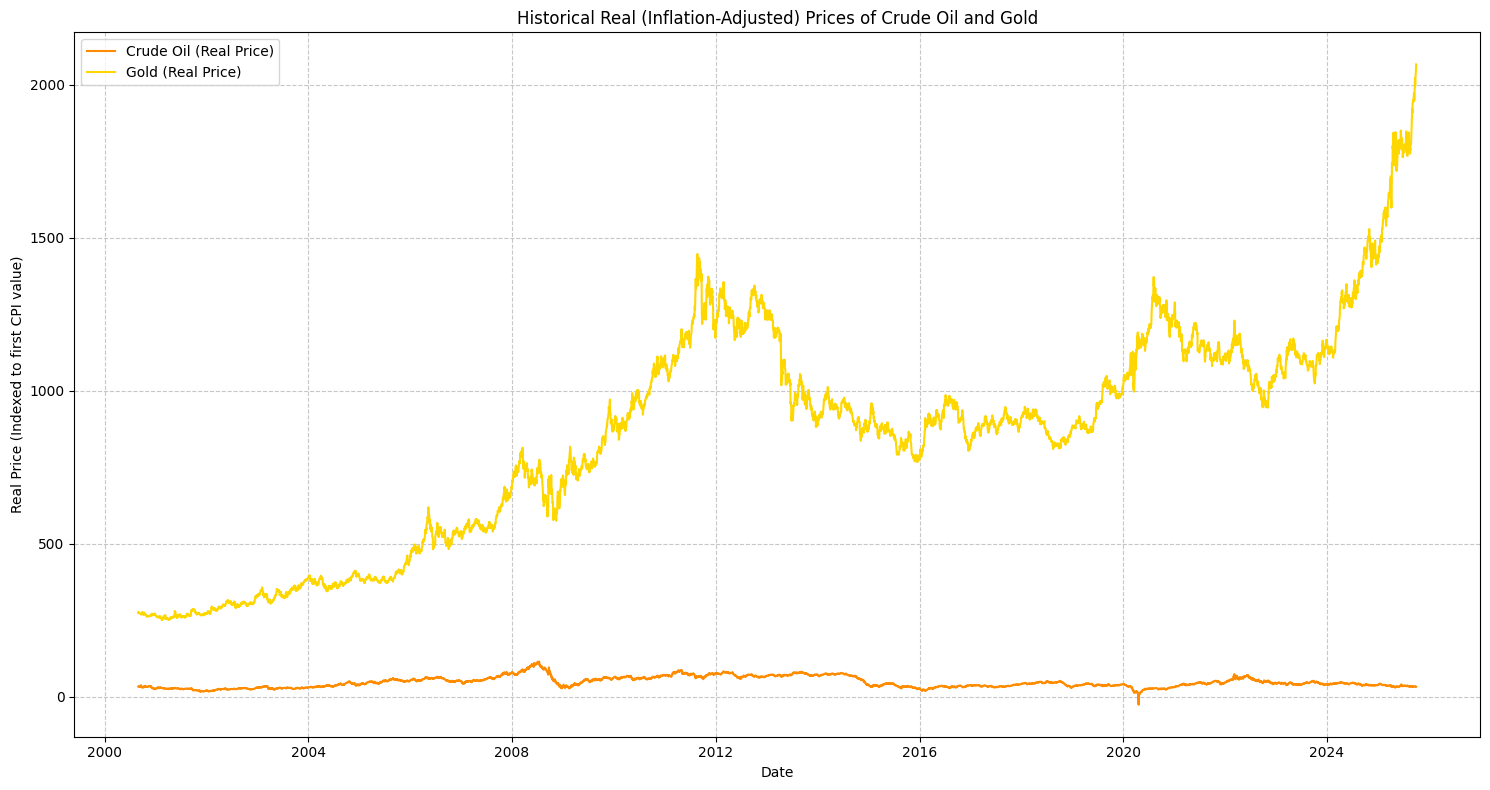

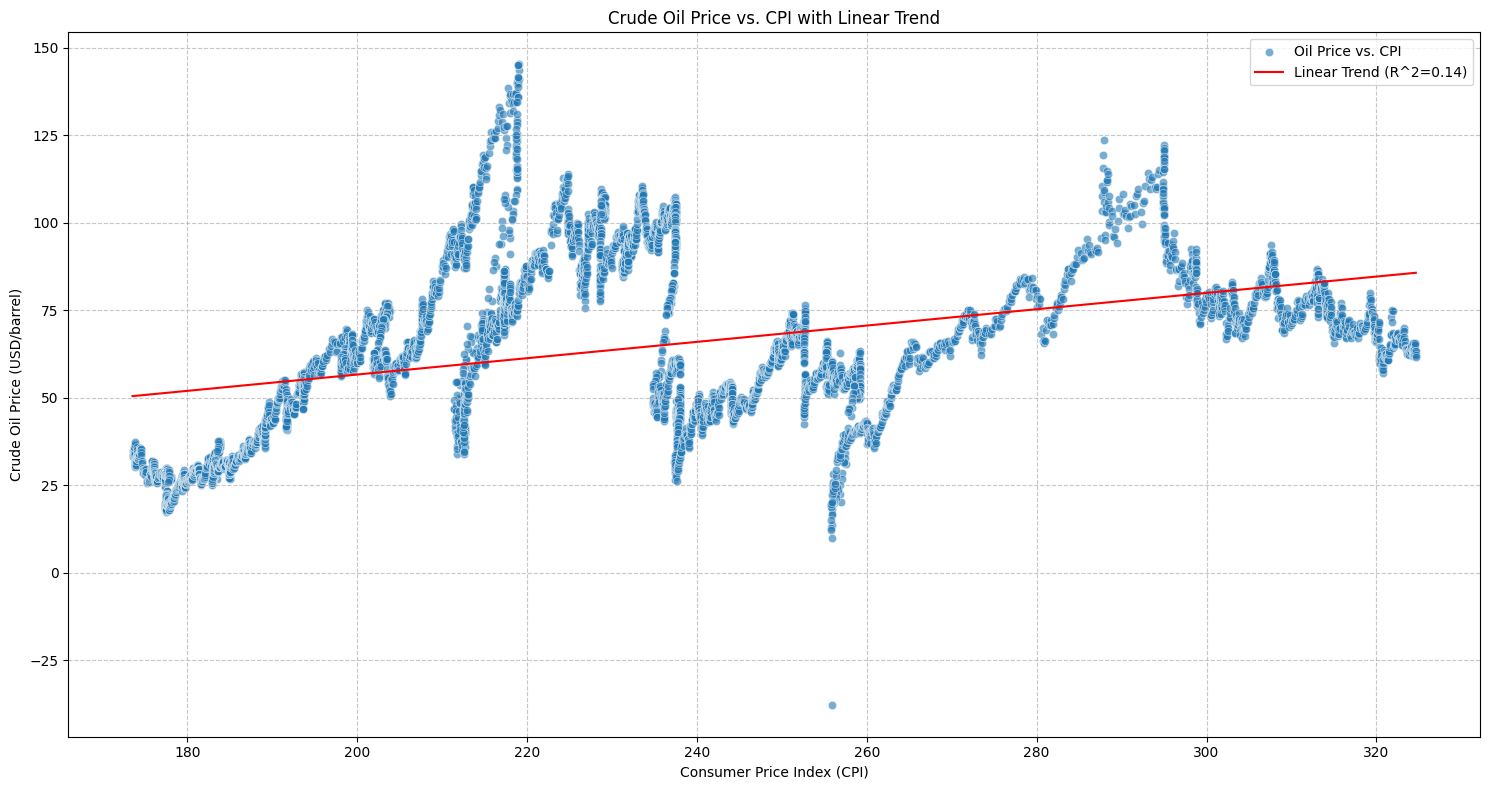

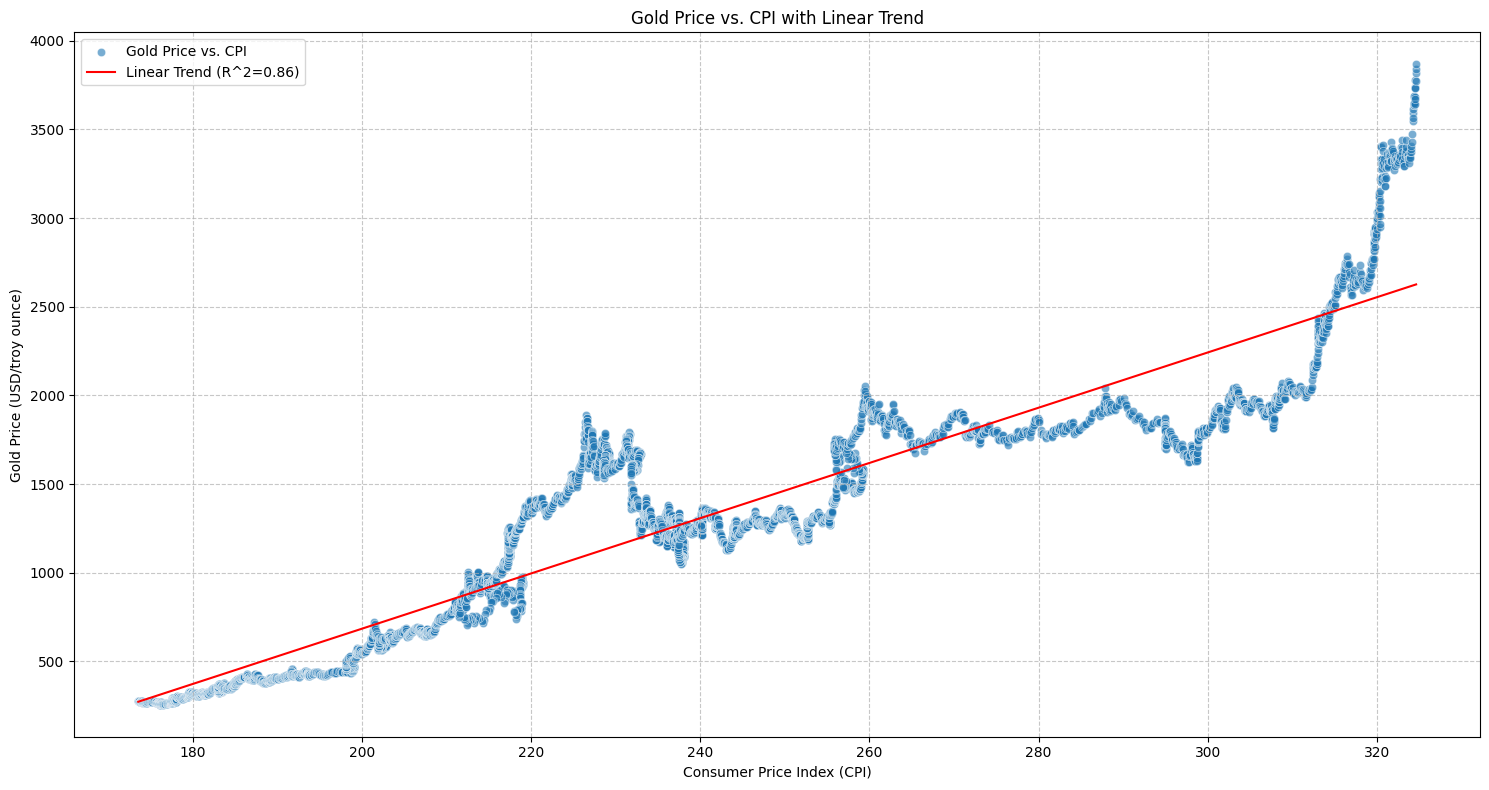

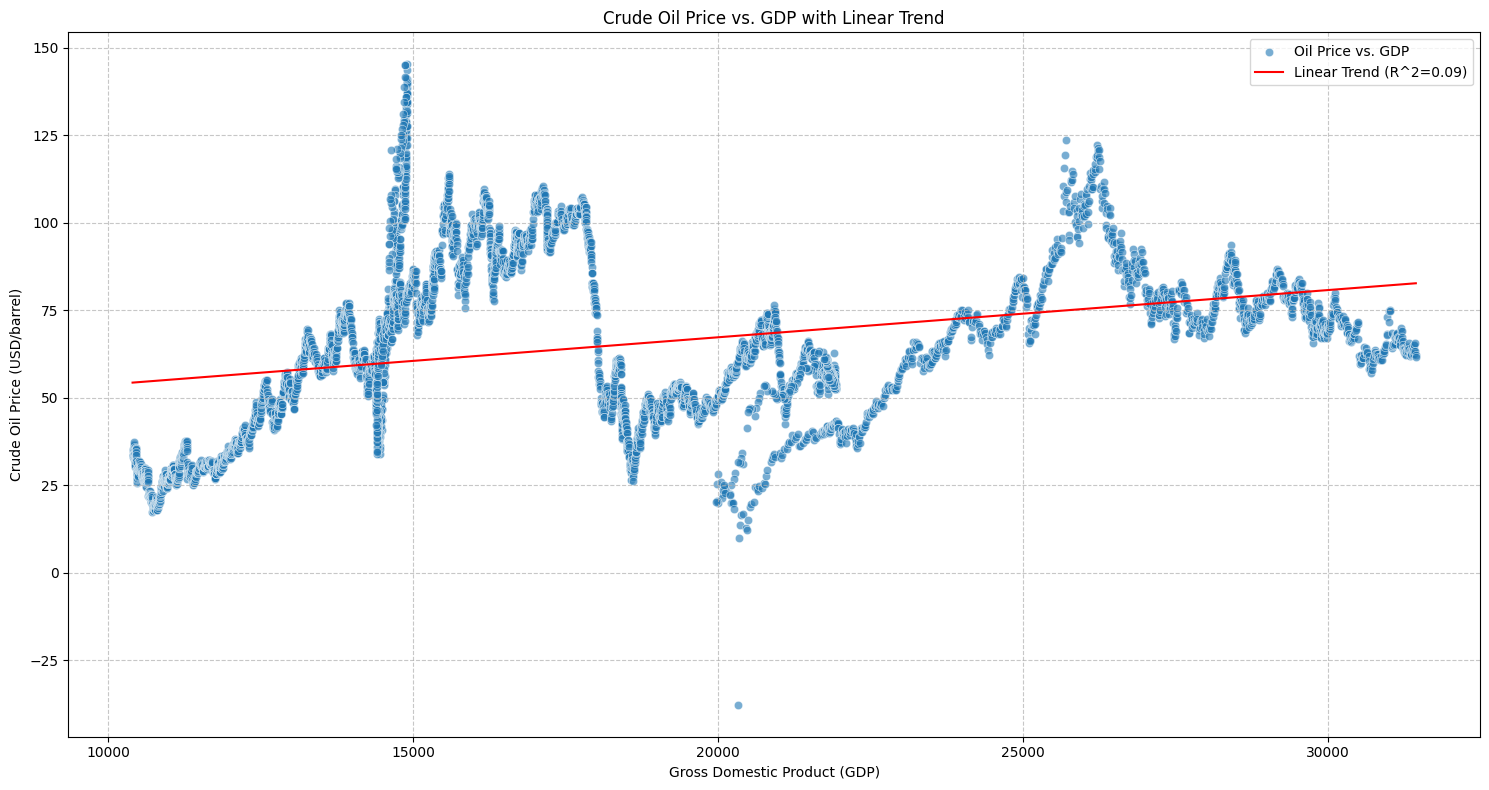

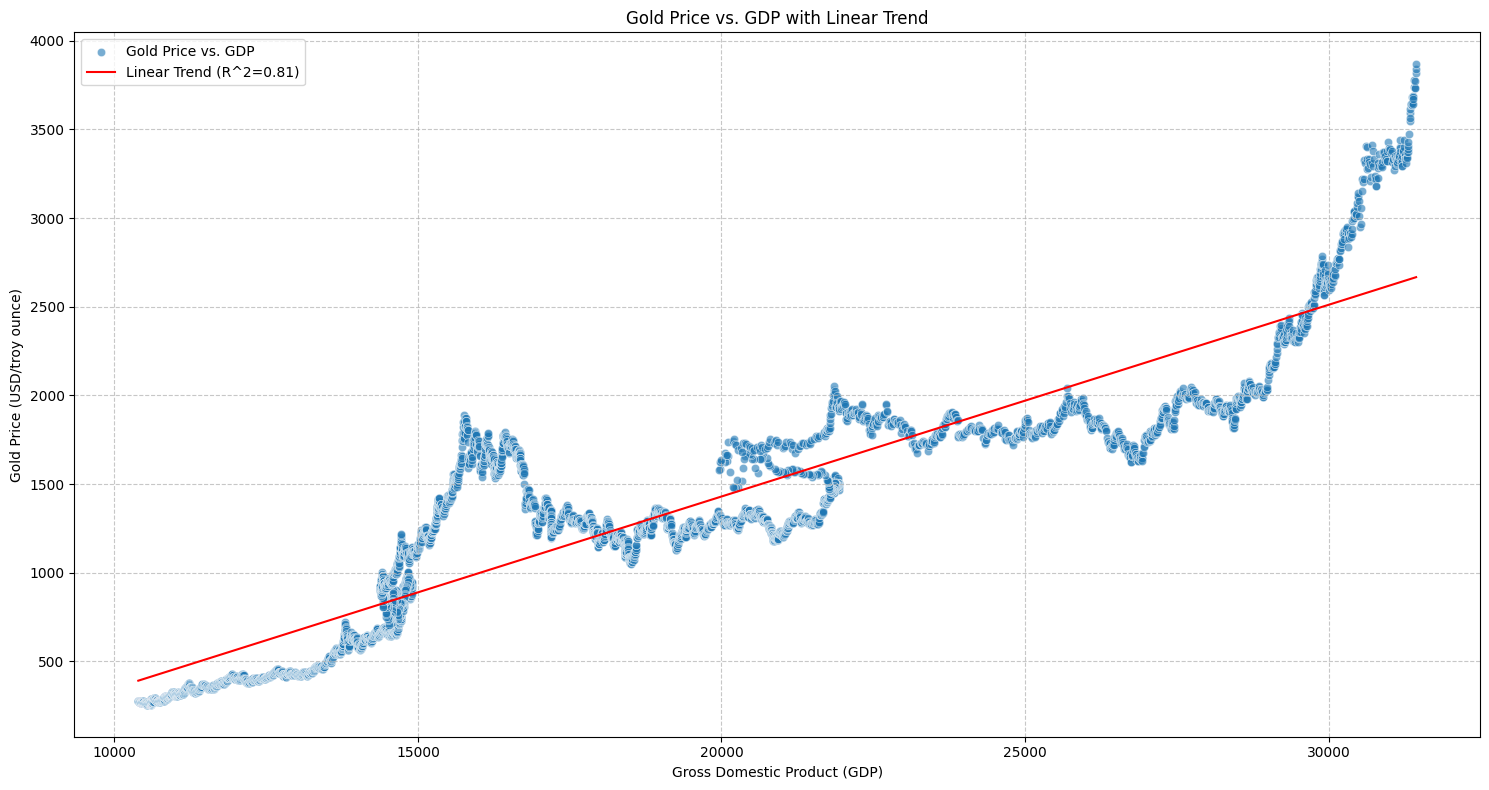

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

# Ensure CPI data is compatible with commodity data frequency
# CPI data is monthly, commodity data is daily. We need to resample and interpolate.
cpi_data.index = pd.to_datetime(cpi_data.index)

# Assuming combined_data has 'Oil_Close' and 'Gold_Close' columns from abc14c11

# Resample CPI to daily and interpolate missing values
daily_cpi = cpi_data['CPI'].resample('D').mean().interpolate(method='linear')

# Merge daily_cpi into combined_data
# Use 'inner' merge to only keep dates where both have data
merged_economic_data = combined_data.merge(daily_cpi.to_frame(), left_index=True, right_index=True, how='inner')

# Ensure GDP data is compatible. GDP is quarterly, need to resample and interpolate.
gdp_data.index = pd.to_datetime(gdp_data.index)
daily_gdp = gdp_data['GDP'].resample('D').mean().interpolate(method='linear')

# Merge daily_gdp into merged_economic_data
merged_economic_data = merged_economic_data.merge(daily_gdp.to_frame(), left_index=True, right_index=True, how='inner')

# Calculate inflation-adjusted prices
# We'll use the first CPI value as the base for adjustment
base_cpi = merged_economic_data['CPI'].iloc[0]
merged_economic_data['Oil_Real_Price'] = (merged_economic_data['Oil_Close'] / merged_economic_data['CPI']) * base_cpi
merged_economic_data['Gold_Real_Price'] = (merged_economic_data['Gold_Close'] / merged_economic_data['CPI']) * base_cpi

print("Merged Economic Data Head (with Real Prices):")
display(merged_economic_data.head())

# --- 2. Generate New Graphs ---

# Graph 1: Historical Real (Inflation-Adjusted) Prices of Oil and Gold
plt.figure(figsize=(15, 8))
plt.plot(merged_economic_data.index, merged_economic_data['Oil_Real_Price'], label='Crude Oil (Real Price)', color='darkorange')
plt.plot(merged_economic_data.index, merged_economic_data['Gold_Real_Price'], label='Gold (Real Price)', color='gold')
plt.title('Historical Real (Inflation-Adjusted) Prices of Crude Oil and Gold')
plt.xlabel('Date')
plt.ylabel('Real Price (Indexed to first CPI value)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Graph 2: Oil Prices vs. CPI with Linear Tendency
plt.figure(figsize=(15, 8))
sns.scatterplot(x='CPI', y='Oil_Close', data=merged_economic_data, alpha=0.6, label='Oil Price vs. CPI')

# Add linear regression line
lin_reg_oil_cpi = linregress(merged_economic_data['CPI'], merged_economic_data['Oil_Close'])
plt.plot(merged_economic_data['CPI'], lin_reg_oil_cpi.intercept + lin_reg_oil_cpi.slope * merged_economic_data['CPI'], color='red', label=f'Linear Trend (R^2={lin_reg_oil_cpi.rvalue**2:.2f})')

plt.title('Crude Oil Price vs. CPI with Linear Trend')
plt.xlabel('Consumer Price Index (CPI)')
plt.ylabel('Crude Oil Price (USD/barrel)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Graph 3: Gold Prices vs. CPI with Linear Tendency
plt.figure(figsize=(15, 8))
sns.scatterplot(x='CPI', y='Gold_Close', data=merged_economic_data, alpha=0.6, label='Gold Price vs. CPI')

# Add linear regression line
lin_reg_gold_cpi = linregress(merged_economic_data['CPI'], merged_economic_data['Gold_Close'])
plt.plot(merged_economic_data['CPI'], lin_reg_gold_cpi.intercept + lin_reg_gold_cpi.slope * merged_economic_data['CPI'], color='red', label=f'Linear Trend (R^2={lin_reg_gold_cpi.rvalue**2:.2f})')

plt.title('Gold Price vs. CPI with Linear Trend')
plt.xlabel('Consumer Price Index (CPI)')
plt.ylabel('Gold Price (USD/troy ounce)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Graph 4: Oil Prices vs. GDP with Linear Tendency
plt.figure(figsize=(15, 8))
sns.scatterplot(x='GDP', y='Oil_Close', data=merged_economic_data, alpha=0.6, label='Oil Price vs. GDP')

# Add linear regression line
lin_reg_oil_gdp = linregress(merged_economic_data['GDP'], merged_economic_data['Oil_Close'])
plt.plot(merged_economic_data['GDP'], lin_reg_oil_gdp.intercept + lin_reg_oil_gdp.slope * merged_economic_data['GDP'], color='red', label=f'Linear Trend (R^2={lin_reg_oil_gdp.rvalue**2:.2f})')

plt.title('Crude Oil Price vs. GDP with Linear Trend')
plt.xlabel('Gross Domestic Product (GDP)')
plt.ylabel('Crude Oil Price (USD/barrel)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Graph 5: Gold Prices vs. GDP with Linear Tendency
plt.figure(figsize=(15, 8))
sns.scatterplot(x='GDP', y='Gold_Close', data=merged_economic_data, alpha=0.6, label='Gold Price vs. GDP')

# Add linear regression line
lin_reg_gold_gdp = linregress(merged_economic_data['GDP'], merged_economic_data['Gold_Close'])
plt.plot(merged_economic_data['GDP'], lin_reg_gold_gdp.intercept + lin_reg_gold_gdp.slope * merged_economic_data['GDP'], color='red', label=f'Linear Trend (R^2={lin_reg_gold_gdp.rvalue**2:.2f})')

plt.title('Gold Price vs. GDP with Linear Trend')
plt.xlabel('Gross Domestic Product (GDP)')
plt.ylabel('Gold Price (USD/troy ounce)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
import pandas_datareader as pdr
import datetime

# Define the start and end dates for fetching data
# We'll use a broad range to cover the commodity data period
start_date = datetime.datetime(2000, 1, 1)
end_date = datetime.datetime.now()

print("Fetching historical CPI data from FRED...")
# Fetch Consumer Price Index (CPI) data (e.g., CPI for All Urban Consumers, All Items, Seasonally Adjusted)
cpi_data = pdr.get_data_fred('CPIAUCSL', start=start_date, end=end_date)
cpi_data.rename(columns={'CPIAUCSL': 'CPI'}, inplace=True)

print("Fetching historical GDP data from FRED...")
# Fetch Gross Domestic Product (GDP) data (e.g., Gross Domestic Product, Seasonally Adjusted Annual Rate)
gdp_data = pdr.get_data_fred('GDP', start=start_date, end=end_date)

print("CPI Data Head:")
display(cpi_data.head())

print("\nGDP Data Head:")
display(gdp_data.head())

Fetching historical CPI data from FRED...
Fetching historical GDP data from FRED...
CPI Data Head:


,CPI
DATE,
2000-01-01,169.3
2000-02-01,170.0
2000-03-01,171.0
2000-04-01,170.9
2000-05-01,171.2



GDP Data Head:


,GDP
DATE,
2000-01-01,10002.179
2000-04-01,10247.720
2000-07-01,10318.165
2000-10-01,10435.744
2001-01-01,10470.231


Now that we have the CPI and GDP data, we can proceed with:

1.  **Adjusting historical Oil and Gold prices for inflation** using the CPI data. This will give us 'real' prices, removing the effect of general price level changes.
2.  **Integrating GDP data** into our analysis to observe how these macroeconomic indicators correlate with commodity prices.

Forecasting future inflationary peaks would be a subsequent, more complex task requiring dedicated time series forecasting models for inflation itself.

### Graphical Linear Analysis: Scatter Plot of Daily Percentage Changes

/tmp/ipykernel_677/800952646.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  oil_data = yf.download(oil_ticker, period=period)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_677/800952646.py:17: FutureWarning: YF.download() has changed argument auto_adjust default to True
  gold_data = yf.download(gold_ticker, period=period)
[*********************100%***********************]  1 of 1 completed


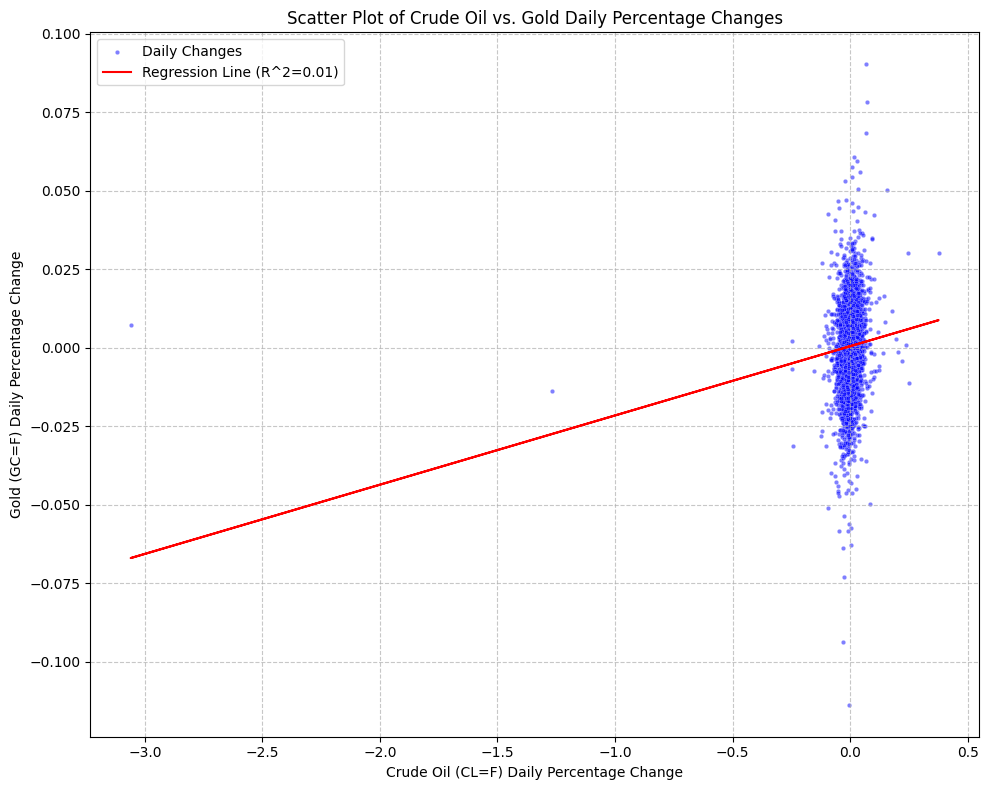

Linear Regression Results for Oil vs. Gold Daily Changes:
  Slope: 0.0220
  Intercept: 0.0005
  R-squared: 0.0093
  P-value: 0.0000


In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

# Define ticker symbols for Oil and Gold futures
oil_ticker = 'CL=F'
gold_ticker = 'GC=F'
period = 'max'

# Fetch data for Oil
oil_data = yf.download(oil_ticker, period=period)
oil_data = oil_data[['Close']].rename(columns={'Close': f'{oil_ticker}_Close'})

# Fetch data for Gold
gold_data = yf.download(gold_ticker, period=period)
gold_data = gold_data[['Close']].rename(columns={'Close': f'{gold_ticker}_Close'})

# Merge the data into a single DataFrame
combined_data = pd.concat([oil_data, gold_data], axis=1).dropna()

# Flatten MultiIndex columns and rename for simpler access
combined_data.columns = ['Oil_Close', 'Gold_Close']

# Calculate the daily percentage change for correlation analysis
price_changes = combined_data.pct_change().dropna()

# Extract daily percentage changes for Oil and Gold, ensuring they are Series
oil_changes = price_changes['Oil_Close'].squeeze()
gold_changes = price_changes['Gold_Close'].squeeze()

# Drop any remaining NaNs in either series to ensure clean plotting
df_scatter = pd.DataFrame({
    'Oil_Daily_Change': oil_changes,
    'Gold_Daily_Change': gold_changes
}).dropna()

# Perform linear regression
lin_regress_results = linregress(df_scatter['Oil_Daily_Change'], df_scatter['Gold_Daily_Change'])

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='Oil_Daily_Change',
    y='Gold_Daily_Change',
    data=df_scatter,
    alpha=0.5,
    s=10,
    color='blue',
    label='Daily Changes'
)

# Add the regression line
plt.plot(
    df_scatter['Oil_Daily_Change'],
    lin_regress_results.intercept + lin_regress_results.slope * df_scatter['Oil_Daily_Change'],
    color='red',
    label=f'Regression Line (R^2={lin_regress_results.rvalue**2:.2f})'
)

plt.title('Scatter Plot of Crude Oil vs. Gold Daily Percentage Changes')
plt.xlabel(f'Crude Oil ({oil_ticker}) Daily Percentage Change')
plt.ylabel(f'Gold ({gold_ticker}) Daily Percentage Change')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Linear Regression Results for Oil vs. Gold Daily Changes:")
print(f"  Slope: {lin_regress_results.slope:.4f}")
print(f"  Intercept: {lin_regress_results.intercept:.4f}")
print(f"  R-squared: {lin_regress_results.rvalue**2:.4f}")
print(f"  P-value: {lin_regress_results.pvalue:.4f}")

### Comprehensive Numerical Grid Output: Comparison of Econometric Measures for Oil and Gold

In [ ]:
import pandas as pd
import yfinance as yf
from statsmodels.tsa.stattools import grangercausalitytests, coint, adfuller

# Define ticker symbols for Oil and Gold futures (needed for Granger and Cointegration)
oil_ticker = 'CL=F'
gold_ticker = 'GC=F'

# Ensure combined_data and price_changes are available from cell abc14c11
# No need to re-fetch data if abc14c11 was run.

# --- Re-run necessary analyses to ensure variables are defined ---

# Granger Causality Test (from 5e985854)
# Prepare the data for Granger Causality Test
df_granger = price_changes[['Oil_Close', 'Gold_Close']].copy()
granger_results_oil_gold = grangercausalitytests(df_granger[['Gold_Close', 'Oil_Close']], maxlag=[5, 20], verbose=False)
granger_results_gold_oil = grangercausalitytests(df_granger[['Oil_Close', 'Gold_Close']], maxlag=[5, 20], verbose=False)

# Cointegration Test (from 11776ce3)
series1_prices = combined_data['Oil_Close']
series2_prices = combined_data['Gold_Close']
coint_t, coint_p_value, coint_critical_values = coint(series1_prices, series2_prices)

# ADF Test (from 3ea17950)
adf_oil = adfuller(price_changes['Oil_Close'].dropna())
adf_gold = adfuller(price_changes['Gold_Close'].dropna())


# --- Collect Results from Previous Analyses ---

# 1. Linear Regression (from abc14c11)
# Assumes lin_regress_results is available from abc14c11 execution
lin_regress_results_summary = {
    'Measure': 'Linear Regression (Oil vs. Gold Daily Changes)',
    'Description': 'Slope and R-squared of daily percentage changes',
    'Result 1': f"Slope: {lin_regress_results.slope:.4f}",
    'Result 2': f"R-squared: {lin_regress_results.rvalue**2:.4f}",
    'Conclusion': f"P-value: {lin_regress_results.pvalue:.4f} (Significant if < 0.05)"
}

# 2. ANOVA for Oil (from 3104e9d5)
# Assumes oil_anova_table is available from 3104e9d5 execution
oil_anova_conclusion = "Significant difference across years" if oil_anova_table['PR(>F)'].iloc[0] < 0.05 else "No significant difference across years"
anova_oil_summary = {
    'Measure': 'ANOVA (Oil Daily Changes by Year)',
    'Description': 'Tests if mean daily change differs by year',
    'Result 1': f"F-statistic: {oil_anova_table['F'].iloc[0]:.4f}",
    'Result 2': f"P-value: {oil_anova_table['PR(>F)'].iloc[0]:.4f}",
    'Conclusion': oil_anova_conclusion
}

# 3. ANOVA for Gold (from 3104e9d5)
# Assumes gold_anova_table is available from 3104e9d5 execution
gold_anova_conclusion = "Significant difference across years" if gold_anova_table['PR(>F)'].iloc[0] < 0.05 else "No significant difference across years"
anova_gold_summary = {
    'Measure': 'ANOVA (Gold Daily Changes by Year)',
    'Description': 'Tests if mean daily change differs by year',
    'Result 1': f"F-statistic: {gold_anova_table['F'].iloc[0]:.4f}",
    'Result 2': f"P-value: {gold_anova_table['PR(>F)'].iloc[0]:.4f}",
    'Conclusion': gold_anova_conclusion
}

# 4. MANOVA (from 2938a499)
# Assumes manova_results is available from 2938a499 execution
manova_summary_str = str(manova_results.mv_test().summary())
manova_p_value_line = [line for line in manova_summary_str.split('\n') if "Wilks' lambda" in line and 'C(Year)' in line]
manova_p_value = float(manova_p_value_line[0].split()[-1]) if manova_p_value_line else None

manova_conclusion = "Significant difference in combined mean vector across years" if manova_p_value and manova_p_value < 0.05 else "No significant difference in combined mean vector across years"
manova_summary = {
    'Measure': 'MANOVA (Oil & Gold Daily Changes by Year)',
    'Description': 'Tests if combined mean vector differs by year',
    'Result 1': f"Wilk's Lambda C(Year) P-value: {manova_p_value:.4f}" if manova_p_value is not None else "Wilk's Lambda C(Year) P-value: N/A",
    'Result 2': 'N/A',
    'Conclusion': manova_conclusion
}

# 5. Granger Causality (re-executed above)
granger_oil_gold_5_p = granger_results_oil_gold[5][0]['ssr_ftest'][1]
granger_gold_oil_5_p = granger_results_gold_oil[5][0]['ssr_ftest'][1]
granger_oil_gold_20_p = granger_results_oil_gold[20][0]['ssr_ftest'][1]
granger_gold_oil_20_p = granger_results_gold_oil[20][0]['ssr_ftest'][1]

granger_summary = {
    'Measure': 'Granger Causality Test',
    'Description': 'Does one series help predict the other?',
    'Result 1': f"Oil -> Gold (Lag 5) P-value: {granger_oil_gold_5_p:.4f} ({'Yes' if granger_oil_gold_5_p < 0.05 else 'No'})",
    'Result 2': f"Gold -> Oil (Lag 5) P-value: {granger_gold_oil_5_p:.4f} ({'Yes' if granger_gold_oil_5_p < 0.05 else 'No'})",
    'Conclusion': f"Oil -> Gold (Lag 20) P-value: {granger_oil_gold_20_p:.4f} ({'Yes' if granger_oil_gold_20_p < 0.05 else 'No'}); Gold -> Oil (Lag 20) P-value: {granger_gold_oil_20_p:.4f} ({'Yes' if granger_gold_oil_20_p < 0.05 else 'No'})"
}

# 6. Cointegration Test (re-executed above)
cointegration_summary = {
    'Measure': 'Cointegration Test (Engle-Granger)',
    'Description': 'Tests for long-term equilibrium relationship',
    'Result 1': f"Test Statistic: {coint_t:.3f}",
    'Result 2': f"P-value: {coint_p_value:.3f}",
    'Conclusion': f"{'Likely cointegrated' if coint_p_value < 0.05 else 'Likely NOT cointegrated'} (Critical Values: 1%:{coint_critical_values[0]:.3f}, 5%:{coint_critical_values[1]:.3f})"
}

# 7. ADF Test (Stationarity) (re-executed above)
adf_oil_summary = {
    'Measure': 'ADF Test (Oil Daily Changes)',
    'Description': 'Tests for stationarity',
    'Result 1': f"ADF Statistic: {adf_oil[0]:.4f}",
    'Result 2': f"P-value: {adf_oil[1]:.4f}",
    'Conclusion': f"{'Stationary' if adf_oil[1] <= 0.05 else 'Non-stationary'}"
}
adf_gold_summary = {
    'Measure': 'ADF Test (Gold Daily Changes)',
    'Description': 'Tests for stationarity',
    'Result 1': f"ADF Statistic: {adf_gold[0]:.4f}",
    'Result 2': f"P-value: {adf_gold[1]:.4f}",
    'Conclusion': f"{'Stationary' if adf_gold[1] <= 0.05 else 'Non-stationary'}"
}

# Combine all summaries into a DataFrame
summary_df = pd.DataFrame([
    lin_regress_results_summary,
    anova_oil_summary,
    anova_gold_summary,
    manova_summary,
    granger_summary,
    cointegration_summary,
    adf_oil_summary,
    adf_gold_summary
])

display(summary_df)

print("\n--- Interpretation Guide ---")
print("For P-values: A value less than 0.05 generally indicates statistical significance.")
print("For Granger Causality and Cointegration: Conclusions are based on the p-value relative to chosen significance levels (e.g., 0.05).")
print("For ADF Test: A p-value <= 0.05 suggests the series is stationary.")

/tmp/ipykernel_677/2562012428.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  oil_data = yf.download(oil_ticker, period=period)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_677/2562012428.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  gold_data = yf.download(gold_ticker, period=period)
[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


,Measure,Description,Result 1,Result 2,Conclusion
0,Linear Regression (Oil vs. Gold Daily Changes),Slope and R-squared of daily percentage changes,Slope: 0.0220,R-squared: 0.0093,P-value: 0.0000 (Significant if < 0.05)
1,ANOVA (Oil Daily Changes by Year),Tests if mean daily change differs by year,F-statistic: 1.0748,P-value: 0.3616,No significant difference across years
2,ANOVA (Gold Daily Changes by Year),Tests if mean daily change differs by year,F-statistic: 0.7633,P-value: 0.7985,No significant difference across years
3,MANOVA (Oil & Gold Daily Changes by Year),Tests if combined mean vector differs by year,Wilk's Lambda C(Year) P-value: N/A,N/A,No significant difference in combined mean vec...
4,Granger Causality Test,Does one series help predict the other?,Oil -> Gold (Lag 5) P-value: 0.0612 (No),Gold -> Oil (Lag 5) P-value: 0.0313 (Yes),Oil -> Gold (Lag 20) P-value: 0.0959 (No); Gol...
5,Cointegration Test (Engle-Granger),Tests for long-term equilibrium relationship,Test Statistic: -3.215,P-value: 0.067,Likely NOT cointegrated (Critical Values: 1%:-...
6,ADF Test (Oil Daily Changes),Tests for stationarity,ADF Statistic: -14.7778,P-value: 0.0000,Stationary
7,ADF Test (Gold Daily Changes),Tests for stationarity,ADF Statistic: -31.8773,P-value: 0.0000,Stationary



--- Interpretation Guide ---
For P-values: A value less than 0.05 generally indicates statistical significance.
For Granger Causality and Cointegration: Conclusions are based on the p-value relative to chosen significance levels (e.g., 0.05).
For ADF Test: A p-value <= 0.05 suggests the series is stationary.


### ANOVA and MANOVA Analysis (Yearly Comparison of Mean Returns)

To apply ANOVA (Analysis of Variance) and MANOVA (Multivariate Analysis of Variance), we need to define groups. A natural way to do this with time series data is to group by a time unit, such as year. We will examine if the *mean daily percentage changes* of Oil and Gold differ significantly across different years.

In [ ]:
import yfinance as yf
import pandas as pd
from scipy.stats import f_oneway
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Define ticker symbols for Oil and Gold futures
oil_ticker = 'CL=F'
gold_ticker = 'GC=F'
period = 'max'

# Fetch data for Oil
oil_data = yf.download(oil_ticker, period=period)
oil_data = oil_data[['Close']].rename(columns={'Close': f'{oil_ticker}_Close'})

# Fetch data for Gold
gold_data = yf.download(gold_ticker, period=period)
gold_data = gold_data[['Close']].rename(columns={'Close': f'{gold_ticker}_Close'})

# Merge the data into a single DataFrame
combined_data = pd.concat([oil_data, gold_data], axis=1).dropna()

# Flatten MultiIndex columns and rename for simpler access and compatibility with statsmodels formulas
combined_data.columns = ['Oil_Close', 'Gold_Close']

# Calculate the daily percentage change for correlation analysis
price_changes = combined_data.pct_change().dropna()

# Add a 'Year' column to the price_changes DataFrame
price_changes['Year'] = price_changes.index.year

print("--- ANOVA for Crude Oil Daily Percentage Changes (by Year) ---")
# ANOVA for Oil
oil_model = ols('Oil_Close ~ C(Year)', data=price_changes).fit()
oil_anova_table = sm.stats.anova_lm(oil_model, typ=2)
display(oil_anova_table)

if oil_anova_table['PR(>F)'][0] < 0.05:
    print(f"Conclusion: There is a statistically significant difference in the mean daily percentage changes of Crude Oil across different years (p-value < 0.05).")
else:
    print(f"Conclusion: There is no statistically significant difference in the mean daily percentage changes of Crude Oil across different years (p-value >= 0.05).")

print("\n--- ANOVA for Gold Daily Percentage Changes (by Year) ---")
# ANOVA for Gold
gold_model = ols('Gold_Close ~ C(Year)', data=price_changes).fit()
gold_anova_table = sm.stats.anova_lm(gold_model, typ=2)
display(gold_anova_table)

if gold_anova_table['PR(>F)'][0] < 0.05:
    print(f"Conclusion: There is a statistically significant difference in the mean daily percentage changes of Gold across different years (p-value < 0.05).")
else:
    print(f"Conclusion: There is no statistically significant difference in the mean daily percentage changes of Gold across different years (p-value >= 0.05).")

/tmp/ipykernel_677/2425439699.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  oil_data = yf.download(oil_ticker, period=period)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_677/2425439699.py:17: FutureWarning: YF.download() has changed argument auto_adjust default to True
  gold_data = yf.download(gold_ticker, period=period)
[*********************100%***********************]  1 of 1 completed

--- ANOVA for Crude Oil Daily Percentage Changes (by Year) ---


,sum_sq,df,F,PR(>F)
C(Year),0.066744,26.0,1.074787,0.361622
Residual,15.243105,6382.0,NaN,NaN


Conclusion: There is no statistically significant difference in the mean daily percentage changes of Crude Oil across different years (p-value >= 0.05).

--- ANOVA for Gold Daily Percentage Changes (by Year) ---


/tmp/ipykernel_677/2425439699.py:38: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if oil_anova_table['PR(>F)'][0] < 0.05:


,sum_sq,df,F,PR(>F)
C(Year),0.002476,26.0,0.763268,0.798546
Residual,0.796175,6382.0,NaN,NaN


Conclusion: There is no statistically significant difference in the mean daily percentage changes of Gold across different years (p-value >= 0.05).


/tmp/ipykernel_677/2425439699.py:49: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if gold_anova_table['PR(>F)'][0] < 0.05:


### MANOVA for Crude Oil and Gold Daily Percentage Changes (by Year)

MANOVA extends ANOVA to situations with multiple dependent variables. Here, our dependent variables are the daily percentage changes of Oil and Gold. We'll test if the *vector of mean daily percentage changes* for Oil and Gold differs across years.

In [ ]:
import yfinance as yf
import pandas as pd
from statsmodels.multivariate.manova import MANOVA

# Define ticker symbols for Oil and Gold futures
oil_ticker = 'CL=F'
gold_ticker = 'GC=F'
period = 'max'

# Fetch data for Oil
oil_data = yf.download(oil_ticker, period=period)
oil_data = oil_data[['Close']].rename(columns={'Close': f'{oil_ticker}_Close'})

# Fetch data for Gold
gold_data = yf.download(gold_ticker, period=period)
gold_data = gold_data[['Close']].rename(columns={'Close': f'{gold_ticker}_Close'})

# Merge the data into a single DataFrame
combined_data = pd.concat([oil_data, gold_data], axis=1).dropna()

# Flatten MultiIndex columns and rename for simpler access and compatibility with statsmodels formulas
combined_data.columns = ['Oil_Close', 'Gold_Close']

# Calculate the daily percentage change for correlation analysis
price_changes = combined_data.pct_change().dropna()

# For MANOVA, we need the dependent variables as a matrix and the independent variable (Year) as a factor.
# Ensure all years have enough observations. Let's filter out years with very few data points if any.

# Prepare data for MANOVA
# Add 'Year' column if not already present from ANOVA
if 'Year' not in price_changes.columns:
    price_changes['Year'] = price_changes.index.year

# Convert Year to categorical type for MANOVA
price_changes_manova = price_changes.copy()
price_changes_manova['Year'] = price_changes_manova['Year'].astype('category')

# Define dependent and independent variables
dependent_vars = price_changes_manova[['Oil_Close', 'Gold_Close']]
independent_var = price_changes_manova['Year']

# Construct the MANOVA formula string
formula = 'Oil_Close + Gold_Close ~ C(Year)'

# Perform MANOVA
# Note: MANOVA requires a balanced design for some tests, or at least enough observations per group.
# The default `MANOVA` class in statsmodels uses a generalized linear model approach.

print("--- MANOVA for Crude Oil and Gold Daily Percentage Changes (by Year) ---")
manova_results = MANOVA.from_formula(formula, data=price_changes_manova)

# Display the Wilk's Lambda test results, which is common for MANOVA
print(manova_results.mv_test().summary())

# Interpretation guidance based on common MANOVA output structure
# Look for the 'P-value' associated with 'C(Year)' for the overall test.
# The 'PR(>F)' column in Wilk's Lambda output indicates the p-value.
# If this p-value is less than 0.05, there's a significant difference in the combined mean vector.

# Extracting p-value for C(Year) from Wilk's Lambda (assuming default output structure)
# This part can be tricky as summary() output is text. A more robust way might be needed for automation.
# For now, we will inspect the output manually.
print("\nInterpretation: In the table above, look at the row for 'C(Year)' and the 'PR(>F)' column under 'Wilks' lambda'.")
print("If this p-value is less than 0.05, it suggests a statistically significant difference in the combined mean daily percentage changes of Oil and Gold across different years.")

/tmp/ipykernel_677/2513944431.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  oil_data = yf.download(oil_ticker, period=period)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_677/2513944431.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  gold_data = yf.download(gold_ticker, period=period)
[*********************100%***********************]  1 of 1 completed


--- MANOVA for Crude Oil and Gold Daily Percentage Changes (by Year) ---
                   Multivariate linear model
                                                                
----------------------------------------------------------------
         Intercept        Value  Num DF   Den DF  F Value Pr > F
----------------------------------------------------------------
            Wilks' lambda 1.0000 2.0000 6381.0000  0.0821 0.9211
           Pillai's trace 0.0000 2.0000 6381.0000  0.0821 0.9211
   Hotelling-Lawley trace 0.0000 2.0000 6381.0000  0.0821 0.9211
      Roy's greatest root 0.0000 2.0000 6381.0000  0.0821 0.9211
----------------------------------------------------------------
                                                                
----------------------------------------------------------------
        C(Year)         Value   Num DF   Den DF   F Value Pr > F
----------------------------------------------------------------
          Wilks' lambda 0.9925 52.000

### Moving Averages for Oil and Gold Prices

To understand the underlying price trends, we can calculate and visualize the moving average of both Oil and Gold prices. A moving average smooths out price fluctuations over a specified period, making it easier to identify trends.

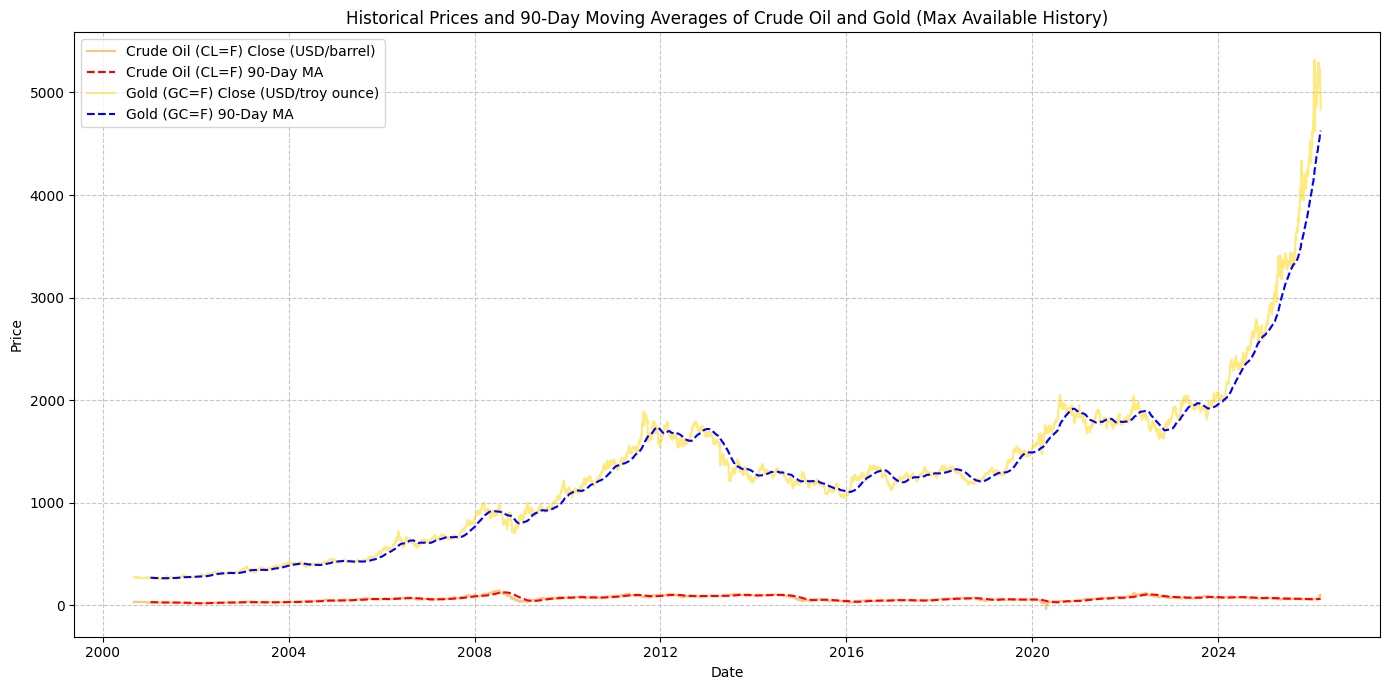

Displaying last few rows of combined_data with 90-day Moving Averages:


Price,CL=F_Close,GC=F_Close,CL=F_MA90,GC=F_MA90
Ticker,CL=F,GC=F,,
Date,,,,
2026-03-12,95.730003,5115.799805,62.764889,4583.893316
2026-03-13,98.709999,5052.500000,63.184111,4595.785539
2026-03-16,93.500000,4994.000000,63.544667,4606.826649
2026-03-17,96.209999,5001.000000,63.940778,4618.529983
2026-03-18,98.650002,4829.899902,64.374667,4627.969982


In [ ]:
# Define a window for the moving average (e.g., 90 days for a quarter)
window = 90

# Calculate the 90-day moving average for Oil and Gold prices
combined_data['Oil_MA' + str(window)] = combined_data['Oil_Close'].rolling(window=window).mean()
combined_data['Gold_MA' + str(window)] = combined_data['Gold_Close'].rolling(window=window).mean()

# Plotting the original prices and their moving averages
plt.figure(figsize=(14, 7))

plt.plot(combined_data.index, combined_data['Oil_Close'], label=f'Crude Oil (CL=F) Close (USD/barrel)', color='darkorange', alpha=0.5)
plt.plot(combined_data.index, combined_data['Oil_MA' + str(window)], label=f'Crude Oil (CL=F) {window}-Day MA', color='red', linestyle='--')

plt.plot(combined_data.index, combined_data['Gold_Close'], label=f'Gold (GC=F) Close (USD/troy ounce)', color='gold', alpha=0.5)
plt.plot(combined_data.index, combined_data['Gold_MA' + str(window)], label=f'Gold (GC=F) {window}-Day MA', color='blue', linestyle='--')

plt.title(f'Historical Prices and {window}-Day Moving Averages of Crude Oil and Gold (Max Available History)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print(f"Displaying last few rows of combined_data with {window}-day Moving Averages:")
display(combined_data.tail())

### Moving Correlation between Oil and Gold

To understand how the relationship (correlation) between Oil and Gold changes over time, we can calculate a rolling (moving) correlation. This helps identify periods where their movements were more or less synchronized.

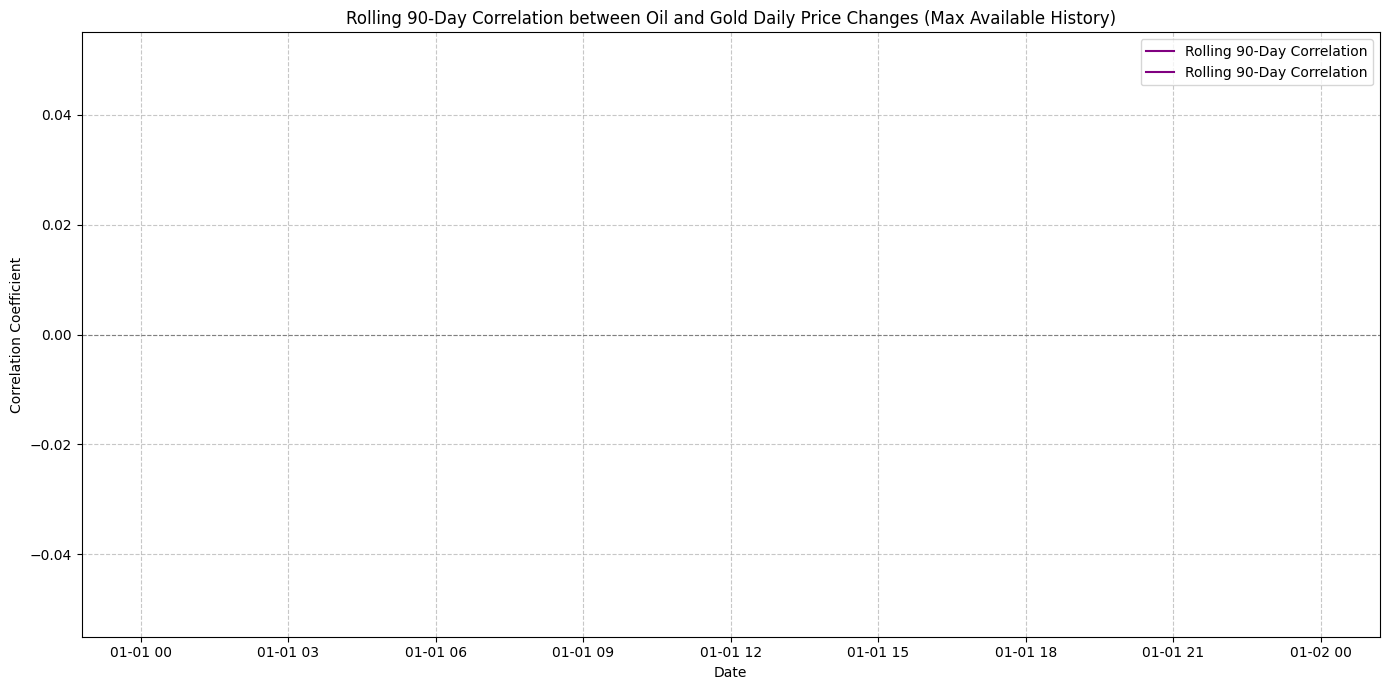

Displaying last few values of 90-day Rolling Correlation:


Ticker,CL=F,GC=F
Date,,
2026-03-12,NaN,NaN
2026-03-13,NaN,NaN
2026-03-16,NaN,NaN
2026-03-17,NaN,NaN
2026-03-18,NaN,NaN


In [ ]:
# Define a window for the moving correlation (consistent with MA, e.g., 90 days)
window = 90

# Calculate the 90-day rolling correlation between Oil and Gold daily percentage changes
moving_correlation = price_changes['Oil_Close'].rolling(window=window).corr(price_changes['Gold_Close'])

# Plotting the moving correlation
plt.figure(figsize=(14, 7))
plt.plot(moving_correlation.index, moving_correlation, label=f'Rolling {window}-Day Correlation', color='purple')

plt.title(f'Rolling {window}-Day Correlation between Oil and Gold Daily Price Changes (Max Available History)')
plt.xlabel('Date')
plt.ylabel('Correlation Coefficient')
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8) # Add a zero line for reference
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print(f"Displaying last few values of {window}-day Rolling Correlation:")
display(moving_correlation.tail())

### Explanation of the Code and Underlying Math

#### 1. Obtaining Gold and Oil Tickers and Data

The code uses the `yfinance` library to fetch historical stock data. Here's a breakdown:

*   **`import yfinance as yf`**: Imports the `yfinance` library, commonly aliased as `yf`.
*   **`oil_ticker = 'CL=F'`** and **`gold_ticker = 'GC=F'`**: These are the ticker symbols used by Yahoo Finance for Crude Oil Futures (`CL=F`) and Gold Futures (`GC=F`).
*   **`yf.download(ticker, period=period)`**: This function is the core of data retrieval. It downloads historical data for a given `ticker` over a specified `period` (e.g., '5y' for 5 years).
*   **`oil_data = oil_data[['Close']].rename(columns={'Close': f'{oil_ticker}_Close'})`**: After downloading, the data contains columns like 'Open', 'High', 'Low', 'Close', 'Adj Close', and 'Volume'. We are only interested in the 'Close' price, so we select it and then rename the column to make it unique and descriptive (e.g., 'CL=F_Close').
*   **`combined_data = pd.concat([oil_data, gold_data], axis=1).dropna()`**: The individual Oil and Gold dataframes are merged side-by-side (`axis=1`) based on their common date index. `.dropna()` is then used to remove any rows where either Oil or Gold data might be missing, ensuring a clean dataset for correlation analysis.

#### 2. Obtaining Gold and Oil Correlation

Correlation measures the statistical relationship between two variables. Here's how it's calculated:

*   **`price_changes = combined_data.pct_change().dropna()`**: To calculate correlation between assets, it's common practice to use *percentage changes* (returns) rather than absolute prices. This is because absolute prices can diverge over time, making correlation misleading. `pct_change()` calculates the daily percentage change for each series (Oil and Gold closing prices). The first row will be `NaN` as there's no prior day to compare with, so `.dropna()` removes it.

    **Algebraic Expression for Percentage Change (Return):**
    The daily percentage change (or return) for an asset `P` at time `t` is calculated as:

    $$ R_t = \frac{P_t - P_{t-1}}{P_{t-1}} \times 100 $$

    Where:
    *   `P_t` is the closing price on the current day.
    *   `P_{t-1}` is the closing price on the previous day.

*   **`correlation_matrix = price_changes.corr()`**: The `.corr()` method on a DataFrame calculates the Pearson correlation coefficient between all pairs of columns. In our case, it computes the correlation between the daily percentage changes of Oil and Gold.

    **Algebraic Expression for Pearson Correlation Coefficient:**
    The Pearson correlation coefficient (r) between two variables, X (Oil's daily changes) and Y (Gold's daily changes), is calculated as:

    $$ r = \frac{n(\sum xy) - (\sum x)(\sum y)}{\sqrt{[n\sum x^2 - (\sum x)^2][n\sum y^2 - (\sum y)^2]}} $$

    Where:
    *   `n` is the number of data points (days).
    *   `Σxy` is the sum of the products of the daily percentage changes of Oil and Gold.
    *   `Σx` is the sum of the daily percentage changes of Oil.
    *   `Σy` is the sum of the daily percentage changes of Gold.
    *   `Σx^2` is the sum of the squares of the daily percentage changes of Oil.
    *   `Σy^2` is the sum of the squares of the daily percentage changes of Gold.

*   **`sns.heatmap(correlation_matrix, annot=True, ...)`**: This uses the `seaborn` library to visualize the `correlation_matrix` as a heatmap. `annot=True` displays the correlation values on the heatmap, making it easy to interpret the strength and direction of the relationship.

### Alpaca-related content removed as per user request.

In [ ]:
### Alpaca-related content removed as per user request.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.5/122.5 kB 2.4 MB/s eta 0:00:00


### Alpaca-related content removed as per user request.

In [ ]:
### Alpaca-related content removed as per user request.

SecretNotFoundError: Secret ALPACA_API_KEY does not exist.

In [ ]:
### Alpaca-related content removed as per user request.

Verifying Alpaca secret key access...
ALPACA_API_KEY is accessible.
Error accessing ALPACA_SECRET_KEY: Secret ALPACA_SECRET_KEY does not exist.. Please ensure it's set in Colab secrets and 'Notebook access' is enabled.
Verification complete.


First, let's define the ticker symbols for Oil and Gold and fetch their historical data using `yfinance`.

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define ticker symbols for Oil and Gold futures
# CL=F: Crude Oil Futures (often represents WTI crude)
# GC=F: Gold Futures
oil_ticker = 'CL=F'
gold_ticker = 'GC=F'

# Define the period for data retrieval (e.g., last 5 years)
# Changed to 'max' to get the maximum available historical data
period = 'max'

print(f"Fetching historical data for {oil_ticker} (Oil) and {gold_ticker} (Gold) for the maximum available period...")

# Fetch data for Oil
oil_data = yf.download(oil_ticker, period=period)
oil_data = oil_data[['Close']].rename(columns={'Close': f'{oil_ticker}_Close'})

# Fetch data for Gold
gold_data = yf.download(gold_ticker, period=period)
gold_data = gold_data[['Close']].rename(columns={'Close': f'{gold_ticker}_Close'})

# Merge the data into a single DataFrame
combined_data = pd.concat([oil_data, gold_data], axis=1).dropna()

print("Combined Data Head:")
display(combined_data.head())

print("\nCombined Data Info:")
combined_data.info()

Fetching historical data for CL=F (Oil) and GC=F (Gold) for the maximum available period...


/tmp/ipykernel_1080/1262670325.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  oil_data = yf.download(oil_ticker, period=period)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_1080/1262670325.py:23: FutureWarning: YF.download() has changed argument auto_adjust default to True
  gold_data = yf.download(gold_ticker, period=period)
[*********************100%***********************]  1 of 1 completed


Combined Data Head:


Price,CL=F_Close,GC=F_Close
Ticker,CL=F,GC=F
Date,,
2000-08-30,33.400002,273.899994
2000-08-31,33.099998,278.299988
2000-09-01,33.380001,277.000000
2000-09-05,33.799999,275.799988
2000-09-06,34.950001,274.200012



Combined Data Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6409 entries, 2000-08-30 to 2026-03-18
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   (CL=F_Close, CL=F)  6409 non-null   float64
 1   (GC=F_Close, GC=F)  6409 non-null   float64
dtypes: float64(2)
memory usage: 150.2 KB


Now, let's visualize the historical price trends of Oil and Gold.

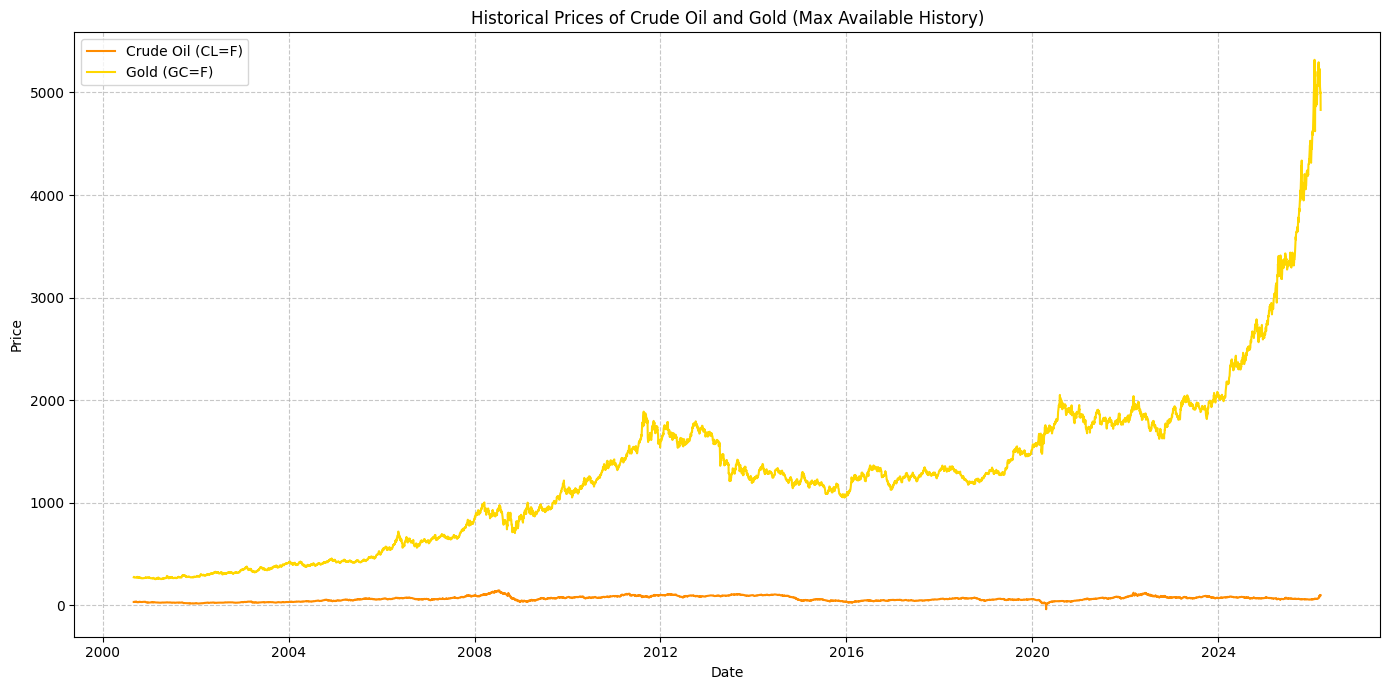

In [ ]:
plt.figure(figsize=(14, 7))

plt.plot(combined_data.index, combined_data[f'{oil_ticker}_Close'], label='Crude Oil (CL=F)', color='darkorange')
plt.plot(combined_data.index, combined_data[f'{gold_ticker}_Close'], label='Gold (GC=F)', color='gold')

plt.title('Historical Prices of Crude Oil and Gold (Max Available History)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

We can also analyze the correlation between Oil and Gold prices to understand their relationship.

Correlation Matrix of Daily Percentage Changes (Max Available History):


,Price,CL=F_Close,GC=F_Close
,Ticker,CL=F,GC=F
Price,Ticker,,
CL=F_Close,CL=F,1.000000,0.096556
GC=F_Close,GC=F,0.096556,1.000000


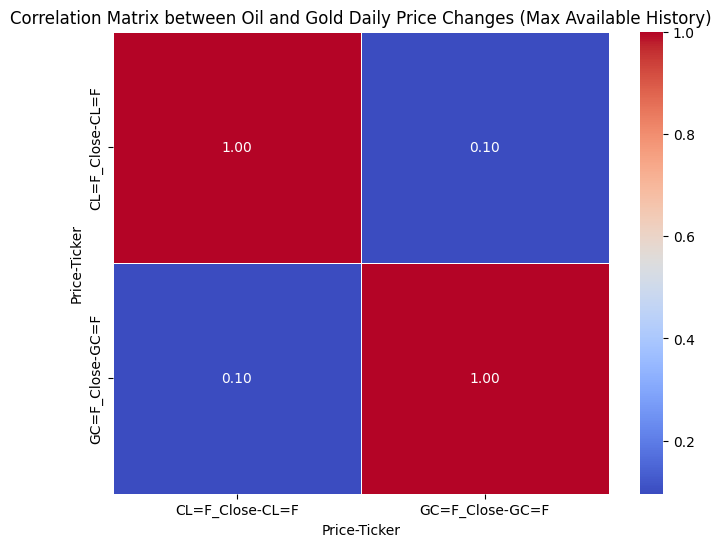

In [ ]:
# Calculate the daily percentage change for correlation analysis
price_changes = combined_data.pct_change().dropna()

# Calculate the correlation matrix
correlation_matrix = price_changes.corr()

print("Correlation Matrix of Daily Percentage Changes (Max Available History):")
display(correlation_matrix)

# Visualize the correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix between Oil and Gold Daily Price Changes (Max Available History)')
plt.show()

### 3. Lead-Lag and Causality Analysis: Granger Causality Test

The Granger Causality test is a statistical hypothesis test for determining whether one time series is useful in forecasting another. A time series X is said to Granger-cause Y if predictions of Y based on its own past values and the past values of X are better than predictions of Y based only on Y's own past values.

In [ ]:
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import grangercausalitytests

# Prepare the data for Granger Causality Test
# The test requires a DataFrame with the two series.
# Let's use the price_changes DataFrame.
# Ensure the DataFrame is clean and contains only the two series for the test.

df_granger = price_changes[[f'{oil_ticker}_Close', f'{gold_ticker}_Close']].copy()

print(f"\n--- Granger Causality Test: Does {oil_ticker} (Oil) Granger-Cause {gold_ticker} (Gold)? ---")
# Test if Oil Granger-causes Gold
# maxlag can be adjusted; 5 for 5 trading days (1 week), 20 for 1 month
granger_results_oil_gold = grangercausalitytests(df_granger[[f'{gold_ticker}_Close', f'{oil_ticker}_Close']], maxlag=[5, 20], verbose=False)

# Interpret results for lag 5
print(f"\nResults for lag 5:")
for test_name, p_value in granger_results_oil_gold[5][0].items():
    print(f"  {test_name} p-value: {p_value[1]:.4f}")
if granger_results_oil_gold[5][0]['ssr_ftest'][1] < 0.05:
    print(f"  Conclusion: Yes, {oil_ticker} Granger-causes {gold_ticker} at lag 5 (p-value < 0.05).")
else:
    print(f"  Conclusion: No, {oil_ticker} does not Granger-cause {gold_ticker} at lag 5 (p-value >= 0.05).")

# Interpret results for lag 20
print(f"\nResults for lag 20:")
for test_name, p_value in granger_results_oil_gold[20][0].items():
    print(f"  {test_name} p-value: {p_value[1]:.4f}")
if granger_results_oil_gold[20][0]['ssr_ftest'][1] < 0.05:
    print(f"  Conclusion: Yes, {oil_ticker} Granger-causes {gold_ticker} at lag 20 (p-value < 0.05).")
else:
    print(f"  Conclusion: No, {oil_ticker} does not Granger-cause {gold_ticker} at lag 20 (p-value >= 0.05).")


print(f"\n--- Granger Causality Test: Does {gold_ticker} (Gold) Granger-Cause {oil_ticker} (Oil)? ---")
# Test if Gold Granger-causes Oil
granger_results_gold_oil = grangercausalitytests(df_granger[[f'{oil_ticker}_Close', f'{gold_ticker}_Close']], maxlag=[5, 20], verbose=False)

# Interpret results for lag 5
print(f"\nResults for lag 5:")
for test_name, p_value in granger_results_gold_oil[5][0].items():
    print(f"  {test_name} p-value: {p_value[1]:.4f}")
if granger_results_gold_oil[5][0]['ssr_ftest'][1] < 0.05:
    print(f"  Conclusion: Yes, {gold_ticker} Granger-causes {oil_ticker} at lag 5 (p-value < 0.05).")
else:
    print(f"  Conclusion: No, {gold_ticker} does not Granger-cause {oil_ticker} at lag 5 (p-value >= 0.05).")

# Interpret results for lag 20
print(f"\nResults for lag 20:")
for test_name, p_value in granger_results_gold_oil[20][0].items():
    print(f"  {test_name} p-value: {p_value[1]:.4f}")
if granger_results_gold_oil[20][0]['ssr_ftest'][1] < 0.05:
    print(f"  Conclusion: Yes, {gold_ticker} Granger-causes {oil_ticker} at lag 20 (p-value < 0.05).")
else:
    print(f"  Conclusion: No, {gold_ticker} does not Granger-cause {oil_ticker} at lag 20 (p-value >= 0.05).")


--- Granger Causality Test: Does CL=F (Oil) Granger-Cause GC=F (Gold)? ---


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(



Results for lag 5:
  ssr_ftest p-value: 0.0675
  ssr_chi2test p-value: 0.0669
  lrtest p-value: 0.0671
  params_ftest p-value: 0.0675
  Conclusion: No, CL=F does not Granger-cause GC=F at lag 5 (p-value >= 0.05).

Results for lag 20:
  ssr_ftest p-value: 0.1243
  ssr_chi2test p-value: 0.1192
  lrtest p-value: 0.1207
  params_ftest p-value: 0.1243
  Conclusion: No, CL=F does not Granger-cause GC=F at lag 20 (p-value >= 0.05).

--- Granger Causality Test: Does GC=F (Gold) Granger-Cause CL=F (Oil)? ---

Results for lag 5:
  ssr_ftest p-value: 0.0318
  ssr_chi2test p-value: 0.0314
  lrtest p-value: 0.0315
  params_ftest p-value: 0.0318
  Conclusion: Yes, GC=F Granger-causes CL=F at lag 5 (p-value < 0.05).

Results for lag 20:
  ssr_ftest p-value: 0.0000
  ssr_chi2test p-value: 0.0000
  lrtest p-value: 0.0000
  params_ftest p-value: 0.0000
  Conclusion: Yes, GC=F Granger-causes CL=F at lag 20 (p-value < 0.05).


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


### 5. Stationarity and Cointegration Tests: Cointegration Test

While the Augmented Dickey-Fuller (ADF) test checked for stationarity of individual series (daily percentage changes), a cointegration test checks for a long-term, stable relationship between two *non-stationary* time series. If two series are cointegrated, it means they tend to move together over the long run, even if they wander independently in the short term. For this test, we typically use the original price series, which are usually non-stationary.

In [ ]:
from statsmodels.tsa.stattools import coint

print("\n--- Cointegration Test (Engle-Granger) for Crude Oil and Gold Prices ---")

# Perform the Engle-Granger two-step cointegration test on the original price series
# The coint function returns: (t-statistic, p-value, critical_values)

# Ensure both series are aligned and have the same length
# We'll use the combined_data which contains the original prices (Oil_Close and Gold_Close)
series1_prices = combined_data['Oil_Close']
series2_prices = combined_data['Gold_Close']

coint_t, coint_p_value, coint_critical_values = coint(series1_prices, series2_prices)

print(f'Test Statistic: {coint_t:.3f}')
print(f'p-value: {coint_p_value:.3f}')
print('Critical Values:')
# Critical values are typically returned as an array [1% critical value, 5% critical value, 10% critical value]
print(f'\t1%: {coint_critical_values[0]:.3f}')
print(f'\t5%: {coint_critical_values[1]:.3f}')
print(f'\t10%: {coint_critical_values[2]:.3f}')

if coint_p_value < 0.05:
    print(f"Conclusion: The price series of {oil_ticker} and {gold_ticker} are likely cointegrated (p-value < 0.05).")
    print("This suggests a long-term equilibrium relationship between them.")
else:
    print(f"Conclusion: The price series of {oil_ticker} and {gold_ticker} are likely NOT cointegrated (p-value >= 0.05).")
    print("This suggests no long-term equilibrium relationship.")


--- Cointegration Test (Engle-Granger) for Crude Oil and Gold Prices ---
Test Statistic: -3.157
p-value: 0.077
Critical Values:
	1%: -3.898
	5%: -3.337
	10%: -3.045
Conclusion: The price series of CL=F and GC=F are likely NOT cointegrated (p-value >= 0.05).
This suggests no long-term equilibrium relationship.


### 3. Lead-Lag and Causality Analysis: Granger Causality Test

The Granger Causality test is a statistical hypothesis test for determining whether one time series is useful in forecasting another. A time series X is said to Granger-cause Y if predictions of Y based on its own past values and the past values of X are better than predictions of Y based only on Y's own past values.

In [ ]:
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import grangercausalitytests

# Define ticker symbols for Oil and Gold futures
oil_ticker = 'CL=F'
gold_ticker = 'GC=F'

# price_changes should be available from cell abc14c11

# Prepare the data for Granger Causality Test
# The test requires a DataFrame with the two series.
# Ensure the DataFrame is clean and contains only the two series for the test.

df_granger = price_changes[['Oil_Close', 'Gold_Close']].copy()

print(f"\n--- Granger Causality Test: Does {oil_ticker} (Oil) Granger-Cause {gold_ticker} (Gold)? ---")
# Test if Oil Granger-causes Gold
# maxlag can be adjusted; 5 for 5 trading days (1 week), 20 for 1 month
granger_results_oil_gold = grangercausalitytests(df_granger[['Gold_Close', 'Oil_Close']], maxlag=[5, 20], verbose=False)

# Interpret results for lag 5
print(f"\nResults for lag 5:")
for test_name, p_value in granger_results_oil_gold[5][0].items():
    print(f"  {test_name} p-value: {p_value[1]:.4f}")
if granger_results_oil_gold[5][0]['ssr_ftest'][1] < 0.05:
    print(f"  Conclusion: Yes, {oil_ticker} Granger-causes {gold_ticker} at lag 5 (p-value < 0.05).")
else:
    print(f"  Conclusion: No, {oil_ticker} does not Granger-cause {gold_ticker} at lag 5 (p-value >= 0.05).")

# Interpret results for lag 20
print(f"\nResults for lag 20:")
for test_name, p_value in granger_results_oil_gold[20][0].items():
    print(f"  {test_name} p-value: {p_value[1]:.4f}")
if granger_results_oil_gold[20][0]['ssr_ftest'][1] < 0.05:
    print(f"  Conclusion: Yes, {oil_ticker} Granger-causes {gold_ticker} at lag 20 (p-value < 0.05).")
else:
    print(f"  Conclusion: No, {oil_ticker} does not Granger-cause {gold_ticker} at lag 20 (p-value >= 0.05).")


print(f"\n--- Granger Causality Test: Does {gold_ticker} (Gold) Granger-Cause {oil_ticker} (Oil)? ---")
# Test if Gold Granger-causes Oil
granger_results_gold_oil = grangercausalitytests(df_granger[['Oil_Close', 'Gold_Close']], maxlag=[5, 20], verbose=False)

# Interpret results for lag 5
print(f"\nResults for lag 5:")
for test_name, p_value in granger_results_gold_oil[5][0].items():
    print(f"  {test_name} p-value: {p_value[1]:.4f}")
if granger_results_gold_oil[5][0]['ssr_ftest'][1] < 0.05:
    print(f"  Conclusion: Yes, {gold_ticker} Granger-causes {oil_ticker} at lag 5 (p-value < 0.05).")
else:
    print(f"  Conclusion: No, {gold_ticker} does not Granger-cause {oil_ticker} at lag 5 (p-value >= 0.05).")

# Interpret results for lag 20
print(f"\nResults for lag 20:")
for test_name, p_value in granger_results_gold_oil[20][0].items():
    print(f"  {test_name} p-value: {p_value[1]:.4f}")
if granger_results_gold_oil[20][0]['ssr_ftest'][1] < 0.05:
    print(f"  Conclusion: Yes, {gold_ticker} Granger-causes {oil_ticker} at lag 20 (p-value < 0.05).")
else:
    print(f"  Conclusion: No, {gold_ticker} does not Granger-cause {oil_ticker} at lag 20 (p-value >= 0.05).")


--- Granger Causality Test: Does CL=F (Oil) Granger-Cause GC=F (Gold)? ---

Results for lag 5:
  ssr_ftest p-value: 0.0675
  ssr_chi2test p-value: 0.0669
  lrtest p-value: 0.0671
  params_ftest p-value: 0.0675
  Conclusion: No, CL=F does not Granger-cause GC=F at lag 5 (p-value >= 0.05).

Results for lag 20:
  ssr_ftest p-value: 0.1243
  ssr_chi2test p-value: 0.1192
  lrtest p-value: 0.1207
  params_ftest p-value: 0.1243
  Conclusion: No, CL=F does not Granger-cause GC=F at lag 20 (p-value >= 0.05).

--- Granger Causality Test: Does GC=F (Gold) Granger-Cause CL=F (Oil)? ---

Results for lag 5:
  ssr_ftest p-value: 0.0318
  ssr_chi2test p-value: 0.0314
  lrtest p-value: 0.0315
  params_ftest p-value: 0.0318
  Conclusion: Yes, GC=F Granger-causes CL=F at lag 5 (p-value < 0.05).

Results for lag 20:
  ssr_ftest p-value: 0.0000
  ssr_chi2test p-value: 0.0000
  lrtest p-value: 0.0000
  params_ftest p-value: 0.0000
  Conclusion: Yes, GC=F Granger-causes CL=F at lag 20 (p-value < 0.05).


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


### 5. Stationarity and Cointegration Tests: Cointegration Test

While the Augmented Dickey-Fuller (ADF) test checked for stationarity of individual series (daily percentage changes), a cointegration test checks for a long-term, stable relationship between two *non-stationary* time series. If two series are cointegrated, it means they tend to move together over the long run, even if they wander independently in the short term. For this test, we typically use the original price series, which are usually non-stationary.

In [ ]:
from statsmodels.tsa.stattools import coint

print("\n--- Cointegration Test (Engle-Granger) for Crude Oil and Gold Prices ---")

# Perform the Engle-Granger two-step cointegration test on the original price series
# The coint function returns: (t-statistic, p-value, critical_values)

# Ensure both series are aligned and have the same length
# We'll use the combined_data which contains the original prices
series1_prices = combined_data[f'{oil_ticker}_Close']
series2_prices = combined_data[f'{gold_ticker}_Close']

coint_t, coint_p_value, coint_critical_values = coint(series1_prices, series2_prices)

print(f'Test Statistic: {coint_t:.3f}')
print(f'p-value: {coint_p_value:.3f}')
print('Critical Values:')
# Critical values are typically returned as an array [1% critical value, 5% critical value, 10% critical value]
print(f'\t1%: {coint_critical_values[0]:.3f}')
print(f'\t5%: {coint_critical_values[1]:.3f}')
print(f'\t10%: {coint_critical_values[2]:.3f}')

if coint_p_value < 0.05:
    print(f"Conclusion: The price series of {oil_ticker} and {gold_ticker} are likely cointegrated (p-value < 0.05).")
    print("This suggests a long-term equilibrium relationship between them.")
else:
    print(f"Conclusion: The price series of {oil_ticker} and {gold_ticker} are likely NOT cointegrated (p-value >= 0.05).")
    print("This suggests no long-term equilibrium relationship.")


--- Cointegration Test (Engle-Granger) for Crude Oil and Gold Prices ---
Test Statistic: -3.157
p-value: 0.077
Critical Values:
	1%: -3.898
	5%: -3.337
	10%: -3.045
Conclusion: The price series of CL=F and GC=F are likely NOT cointegrated (p-value >= 0.05).
This suggests no long-term equilibrium relationship.


### 1. Rolling Volatility Analysis

Volatility is a key measure of risk. By calculating the rolling standard deviation of daily percentage changes, we can observe how the risk profile of Oil and Gold has evolved over time.

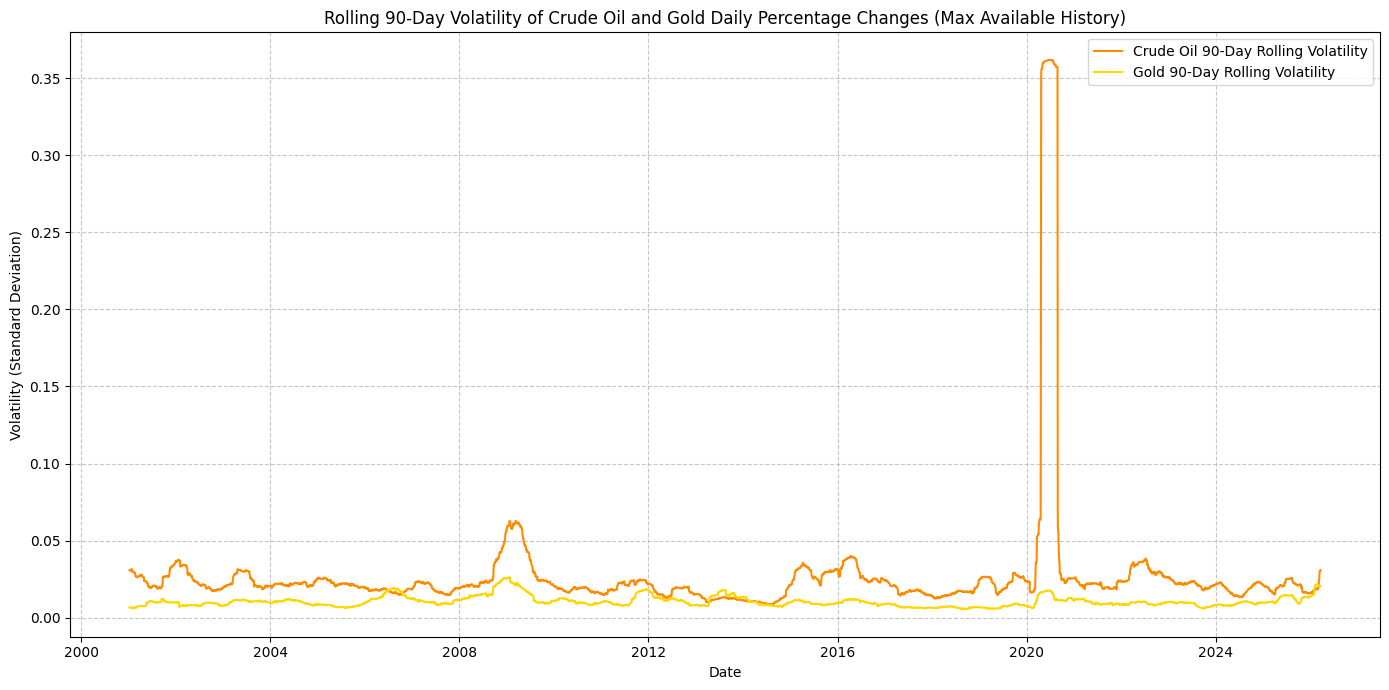

Displaying last few values of 90-day Rolling Volatility for Oil:


Ticker,CL=F
Date,
2026-03-12,0.030069
2026-03-13,0.030190
2026-03-16,0.030812
2026-03-17,0.030881
2026-03-18,0.030864


Displaying last few values of 90-day Rolling Volatility for Gold:


Ticker,GC=F
Date,
2026-03-12,0.020313
2026-03-13,0.020361
2026-03-16,0.020417
2026-03-17,0.020348
2026-03-18,0.020710


In [ ]:
# Define a window for rolling volatility (e.g., 90 days)
volatility_window = 90

# Calculate the rolling standard deviation of daily percentage changes
oil_volatility = price_changes['Oil_Close'].rolling(window=volatility_window).std()
gold_volatility = price_changes['Gold_Close'].rolling(window=volatility_window).std()

# Plotting the rolling volatility
plt.figure(figsize=(14, 7))
plt.plot(oil_volatility.index, oil_volatility, label=f'Crude Oil {volatility_window}-Day Rolling Volatility', color='darkorange')
plt.plot(gold_volatility.index, gold_volatility, label=f'Gold {volatility_window}-Day Rolling Volatility', color='gold')

plt.title(f'Rolling {volatility_window}-Day Volatility of Crude Oil and Gold Daily Percentage Changes (Max Available History)')
plt.xlabel('Date')
plt.ylabel('Volatility (Standard Deviation)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print(f"Displaying last few values of {volatility_window}-day Rolling Volatility for Oil:")
display(oil_volatility.tail())
print(f"Displaying last few values of {volatility_window}-day Rolling Volatility for Gold:")
display(gold_volatility.tail())

### 2. Relative Performance and Ratio Analysis

Understanding the relative performance and the ratio between Oil and Gold can reveal insights into their economic relationship and investor sentiment. A rising Oil/Gold ratio might suggest economic expansion, while a falling ratio could indicate economic stress or a flight to safety (gold).

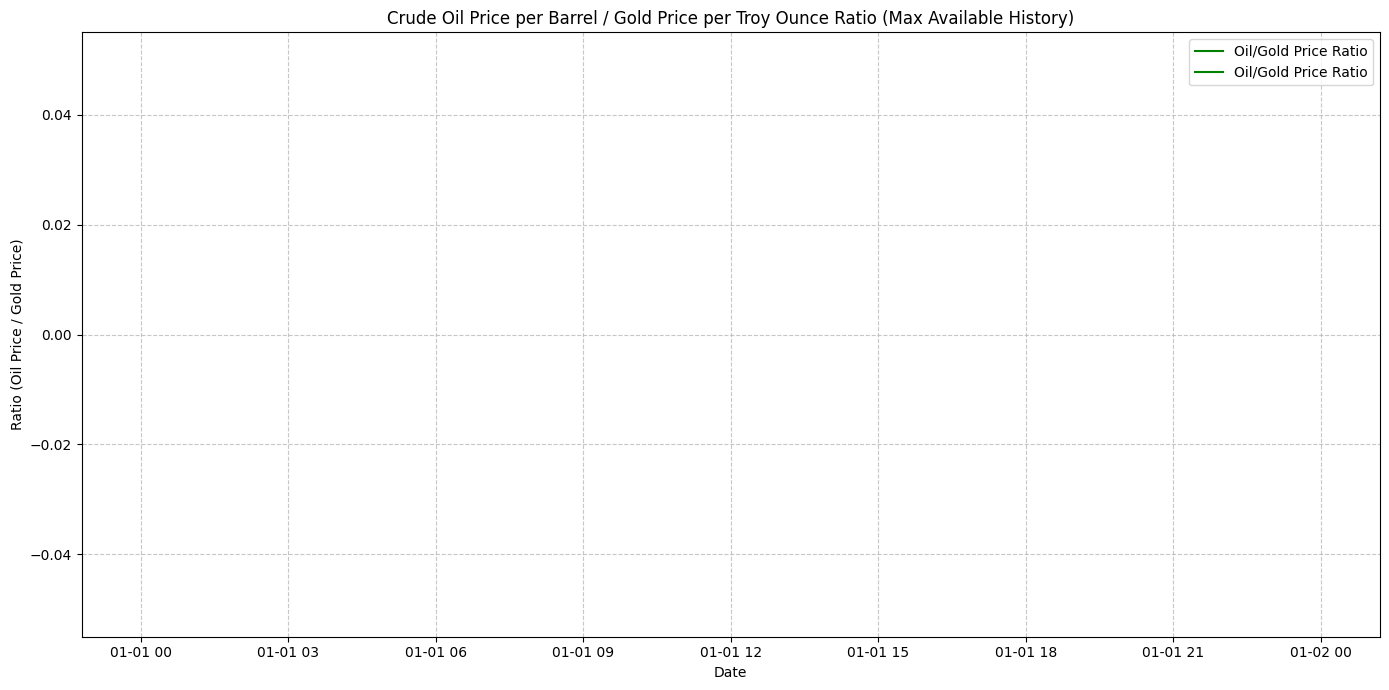

Displaying last few values of Oil/Gold Ratio:


Ticker,CL=F,GC=F
Date,,
2026-03-12,NaN,NaN
2026-03-13,NaN,NaN
2026-03-16,NaN,NaN
2026-03-17,NaN,NaN
2026-03-18,NaN,NaN


In [ ]:
# Calculate the Oil/Gold price ratio
oil_gold_ratio = combined_data['Oil_Close'] / combined_data['Gold_Close']

# Plotting the Oil/Gold Ratio
plt.figure(figsize=(14, 7))
plt.plot(oil_gold_ratio.index, oil_gold_ratio, label='Oil/Gold Price Ratio', color='green')

plt.title('Crude Oil Price per Barrel / Gold Price per Troy Ounce Ratio (Max Available History)')
plt.xlabel('Date')
plt.ylabel('Ratio (Oil Price / Gold Price)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Displaying last few values of Oil/Gold Ratio:")
display(oil_gold_ratio.tail())

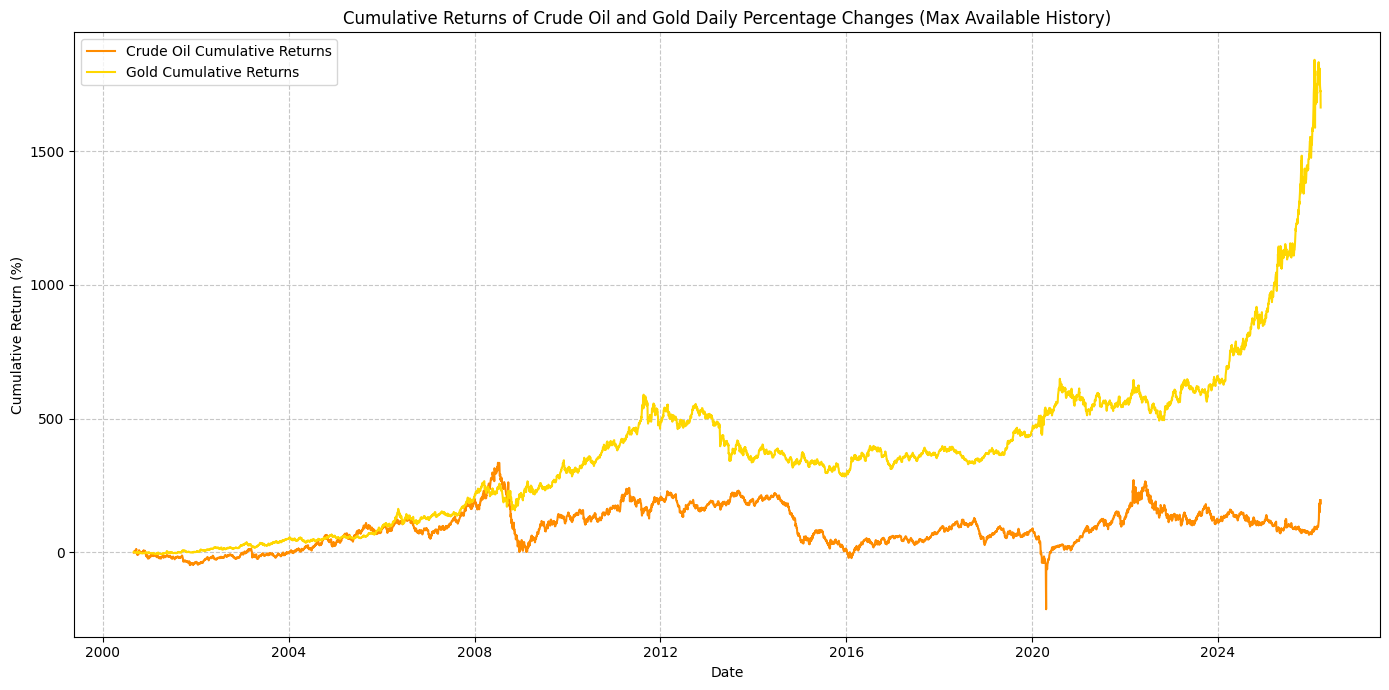

Displaying last few values of Cumulative Returns for Oil:


Ticker,CL=F
Date,
2026-03-12,1.866168
2026-03-13,1.955389
2026-03-16,1.799401
2026-03-17,1.880539
2026-03-18,1.953593


Displaying last few values of Cumulative Returns for Gold:


Ticker,GC=F
Date,
2026-03-12,17.677619
2026-03-13,17.446514
2026-03-16,17.232932
2026-03-17,17.258489
2026-03-18,16.633808


In [ ]:
# Calculate cumulative returns for both assets
# We'll use the price_changes DataFrame which already contains daily percentage changes
cumulative_returns_oil = (1 + price_changes['Oil_Close']).cumprod() - 1
cumulative_returns_gold = (1 + price_changes['Gold_Close']).cumprod() - 1

# Plotting cumulative returns
plt.figure(figsize=(14, 7))
plt.plot(cumulative_returns_oil.index, cumulative_returns_oil * 100, label=f'Crude Oil Cumulative Returns', color='darkorange')
plt.plot(cumulative_returns_gold.index, cumulative_returns_gold * 100, label=f'Gold Cumulative Returns', color='gold')

plt.title('Cumulative Returns of Crude Oil and Gold Daily Percentage Changes (Max Available History)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Displaying last few values of Cumulative Returns for Oil:")
display(cumulative_returns_oil.tail())
print("Displaying last few values of Cumulative Returns for Gold:")
display(cumulative_returns_gold.tail())

### 3. Stationarity Tests (Augmented Dickey-Fuller Test)

Stationarity is a fundamental property for many time series models. A stationary series has statistical properties (mean, variance, autocorrelation) that do not change over time. We will use the Augmented Dickey-Fuller (ADF) test to check for stationarity in the daily percentage changes of Oil and Gold.

In [ ]:
from statsmodels.tsa.stattools import adfuller

# Perform ADF test on Oil daily percentage changes
print(f"\n--- Augmented Dickey-Fuller Test for {oil_ticker} Daily Percentage Changes ---")
adf_oil = adfuller(price_changes['Oil_Close'].dropna())
print('ADF Statistic: %f' % adf_oil[0])
print('p-value: %f' % adf_oil[1])
print('Critical Values:')
for key, value in adf_oil[4].items():
    print('\t%s: %.3f' % (key, value))

if adf_oil[1] <= 0.05:
    print("Result: The series is likely stationary (p-value <= 0.05).")
else:
    print("Result: The series is likely non-stationary (p-value > 0.05).")

# Perform ADF test on Gold daily percentage changes
print(f"\n--- Augmented Dickey-Fuller Test for {gold_ticker} Daily Percentage Changes ---")
adf_gold = adfuller(price_changes['Gold_Close'].dropna())
print('ADF Statistic: %f' % adf_gold[0])
print('p-value: %f' % adf_gold[1])
print('Critical Values:')
for key, value in adf_gold[4].items():
    print('\t%s: %.3f' % (key, value))

if adf_gold[1] <= 0.05:
    print("Result: The series is likely stationary (p-value <= 0.05).")
else:
    print("Result: The series is likely non-stationary (p-value > 0.05).")


--- Augmented Dickey-Fuller Test for CL=F Daily Percentage Changes ---
ADF Statistic: -14.767415
p-value: 0.000000
Critical Values:
	1%: -3.431
	5%: -2.862
	10%: -2.567
Result: The series is likely stationary (p-value <= 0.05).

--- Augmented Dickey-Fuller Test for GC=F Daily Percentage Changes ---
ADF Statistic: -25.385216
p-value: 0.000000
Critical Values:
	1%: -3.431
	5%: -2.862
	10%: -2.567
Result: The series is likely stationary (p-value <= 0.05).


### 3. Lead-Lag and Causality Analysis: Cross-Correlation Function (CCF)

The Cross-Correlation Function (CCF) helps us understand if the price changes of one asset tend to lead or lag the price changes of another asset. A positive correlation at a positive lag `k` means that the first series' values tend to be correlated with the second series' values `k` periods *later*. Conversely, a negative lag `k` means the first series tends to be correlated with the second series `k` periods *earlier*.

/tmp/ipykernel_677/754547597.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  oil_data = yf.download(oil_ticker, period=period)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_677/754547597.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  gold_data = yf.download(gold_ticker, period=period)
[*********************100%***********************]  1 of 1 completed


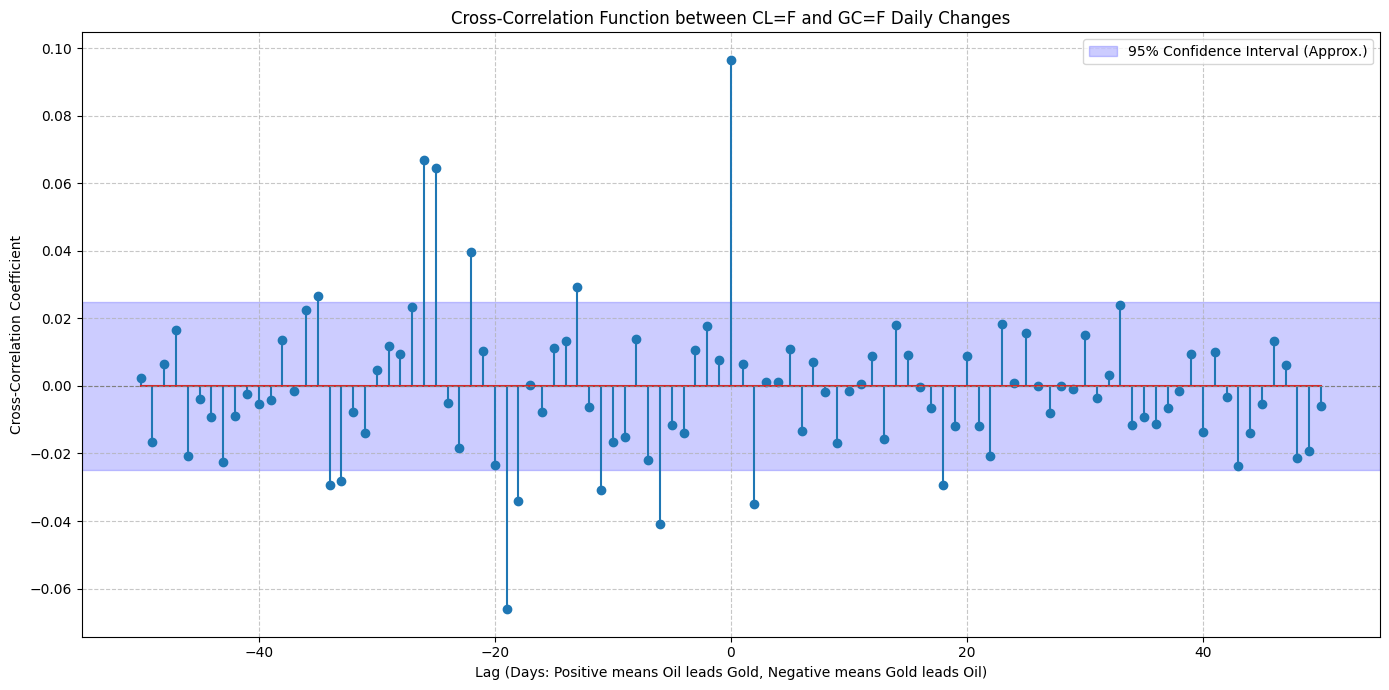

Displaying Cross-Correlation values for selected lags:


,Lag,Correlation
15,-35,0.026680
16,-34,-0.029334
17,-33,-0.028183
24,-26,0.066755
25,-25,0.064439
28,-22,0.039579
31,-19,-0.066105
32,-18,-0.034044
37,-13,0.029338
39,-11,-0.030777


In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import ccf
import numpy as np

# Define ticker symbols for Oil and Gold futures
oil_ticker = 'CL=F'
gold_ticker = 'GC=F'

# combined_data and price_changes should be available from cell abc14c11

# Calculate Cross-Correlation Function for Oil leading Gold
# Lags from -50 to 50 (50 days Oil leads Gold, 50 days Gold leads Oil)

lags = range(-50, 51) # 50 days before to 50 days after
ccf_values = []

# price_changes already calculated: oil_ticker_Close, gold_ticker_Close
series1 = price_changes['Oil_Close']
series2 = price_changes['Gold_Close']

# Combine for symmetrical plot (adjusting lags)
# Let's create a combined CCF with negative and positive lags centered at 0
max_lags = 50
lags_range = range(-max_lags, max_lags + 1)

# Calculate cross-correlation for different lags
cross_correlations = []
for lag in lags_range:
    # Get the relevant numpy arrays, aligning them
    s1_aligned = series1.values
    s2_shifted = series2.shift(-lag)
    s2_shifted_aligned = s2_shifted.values

    # Remove NaNs from both arrays simultaneously for correlation calculation
    valid_indices = ~np.isnan(s1_aligned) & ~np.isnan(s2_shifted_aligned)
    s1_clean = s1_aligned[valid_indices]
    s2_clean = s2_shifted_aligned[valid_indices]

    if len(s1_clean) > 1: # Need at least 2 points for correlation
        corr = np.corrcoef(s1_clean, s2_clean)[0, 1]
    else:
        corr = np.nan # Not enough data to compute correlation

    cross_correlations.append(corr)

# Plotting the Cross-Correlation Function
plt.figure(figsize=(14, 7))
plt.stem(lags_range, cross_correlations)
plt.title(f'Cross-Correlation Function between {oil_ticker} and {gold_ticker} Daily Changes')
plt.xlabel('Lag (Days: Positive means Oil leads Gold, Negative means Gold leads Oil)')
plt.ylabel('Cross-Correlation Coefficient')
plt.grid(True, linestyle='--', alpha=0.7)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
# Add confidence intervals for visual reference (approximate for cross-correlation)
# An approximate confidence interval can be calculated as +/- 2/sqrt(N)
N = len(price_changes) # Number of observations
conf_int = 2 / (N**0.5)
plt.axhspan(-conf_int, conf_int, alpha=0.2, color='blue', label='95% Confidence Interval (Approx.)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Displaying Cross-Correlation values for selected lags:")
cross_corr_df = pd.DataFrame({'Lag': lags_range, 'Correlation': cross_correlations})
display(cross_corr_df[(cross_corr_df['Correlation'].abs() > conf_int).fillna(False)])

### 4. Event Study Analysis: Impact of Global Events

Event study analysis examines the behavior of asset prices around a specific event. We'll pick a few significant historical dates and visualize the price movements of Oil and Gold in the period surrounding these events to see their typical reactions.

/tmp/ipykernel_206/208073306.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  oil_data = yf.download(oil_ticker, period=period)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_206/208073306.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  gold_data = yf.download(gold_ticker, period=period)
[*********************100%***********************]  1 of 1 completed


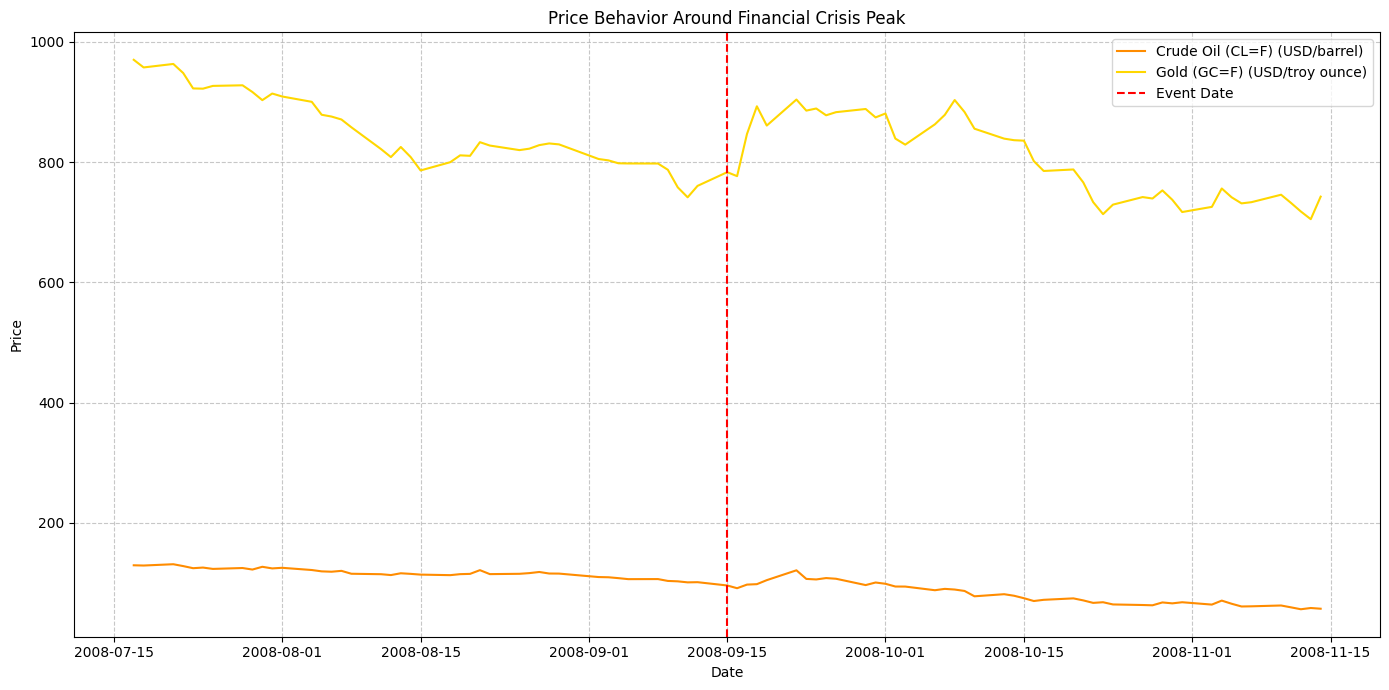

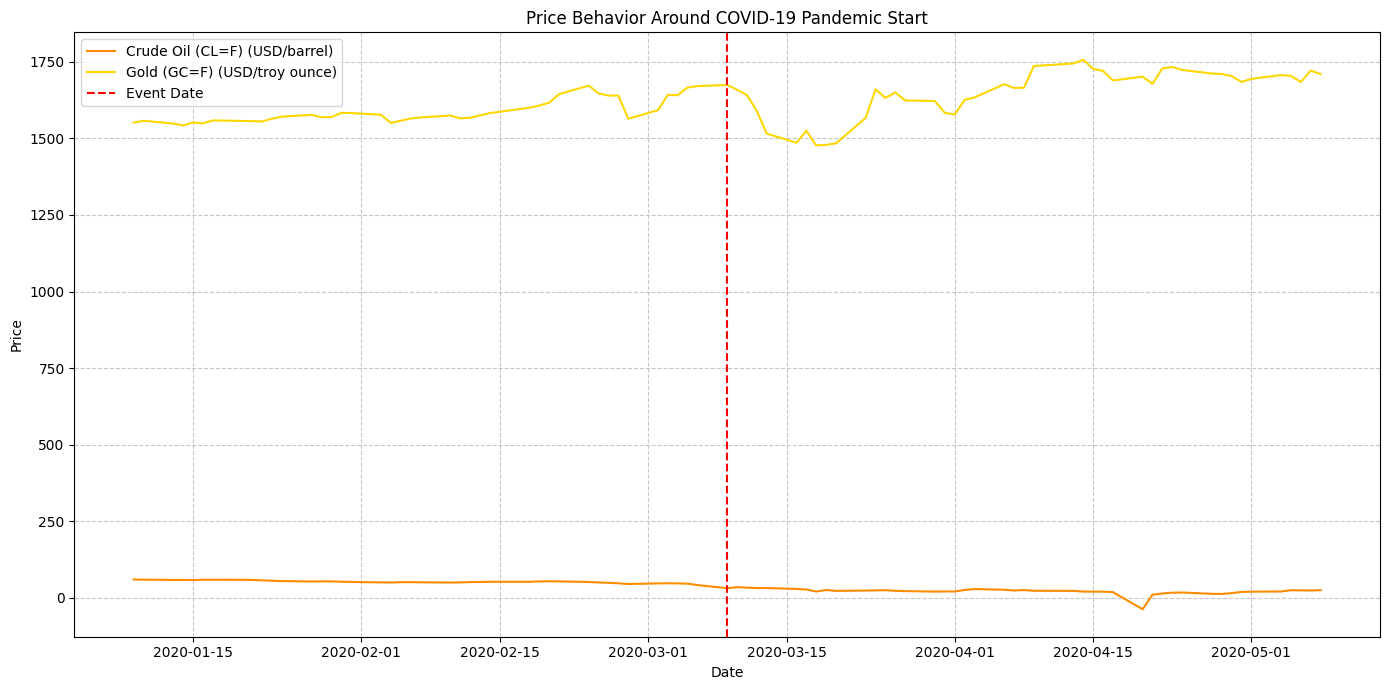

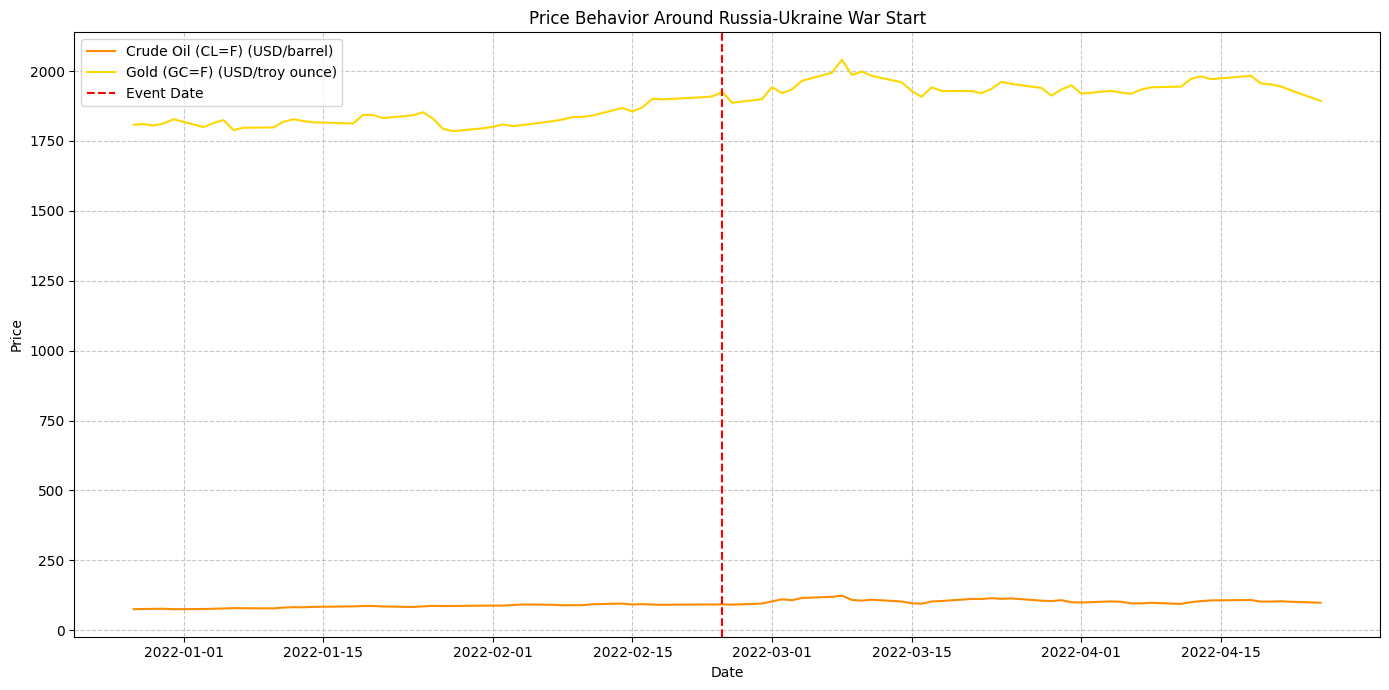

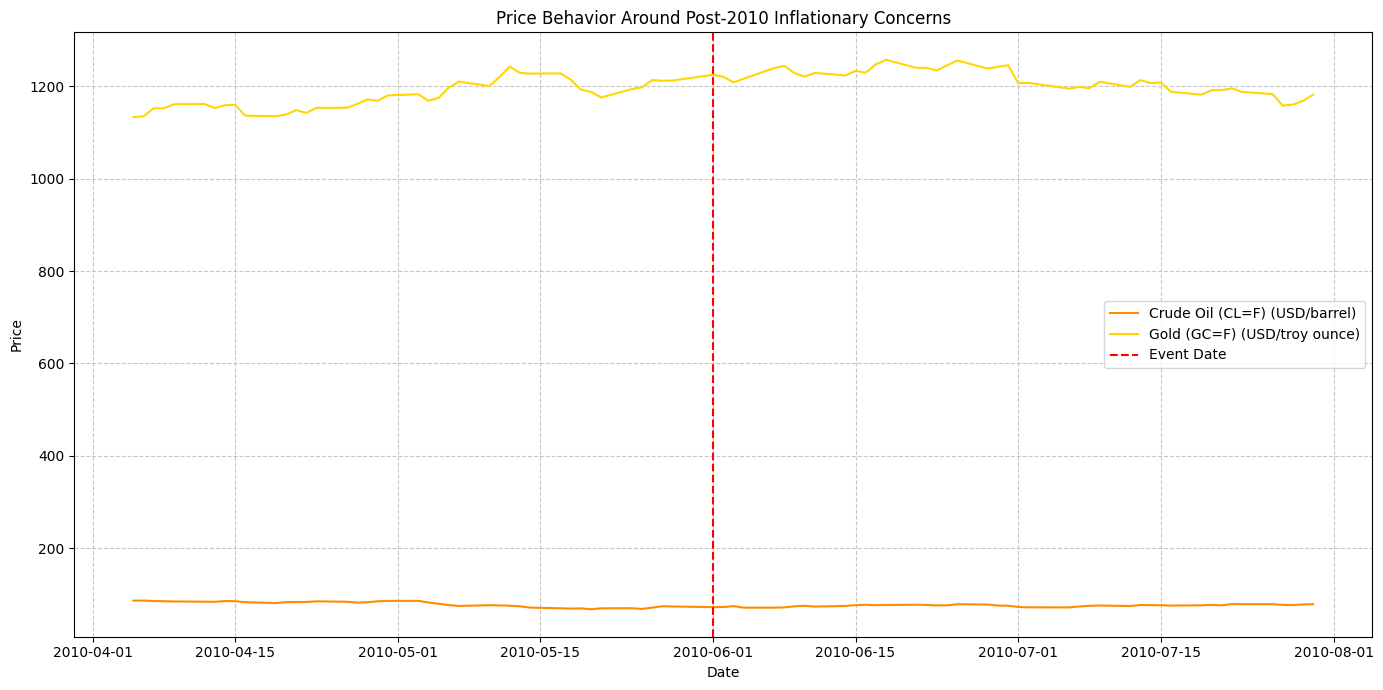

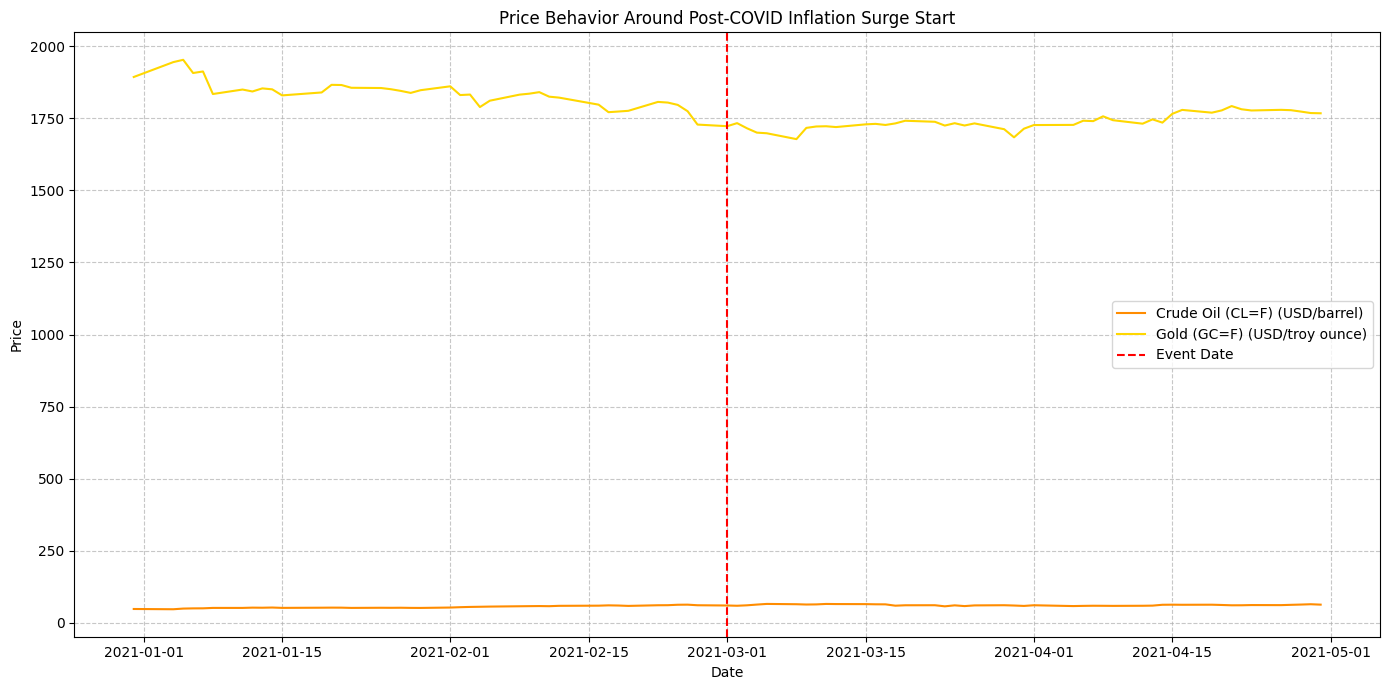

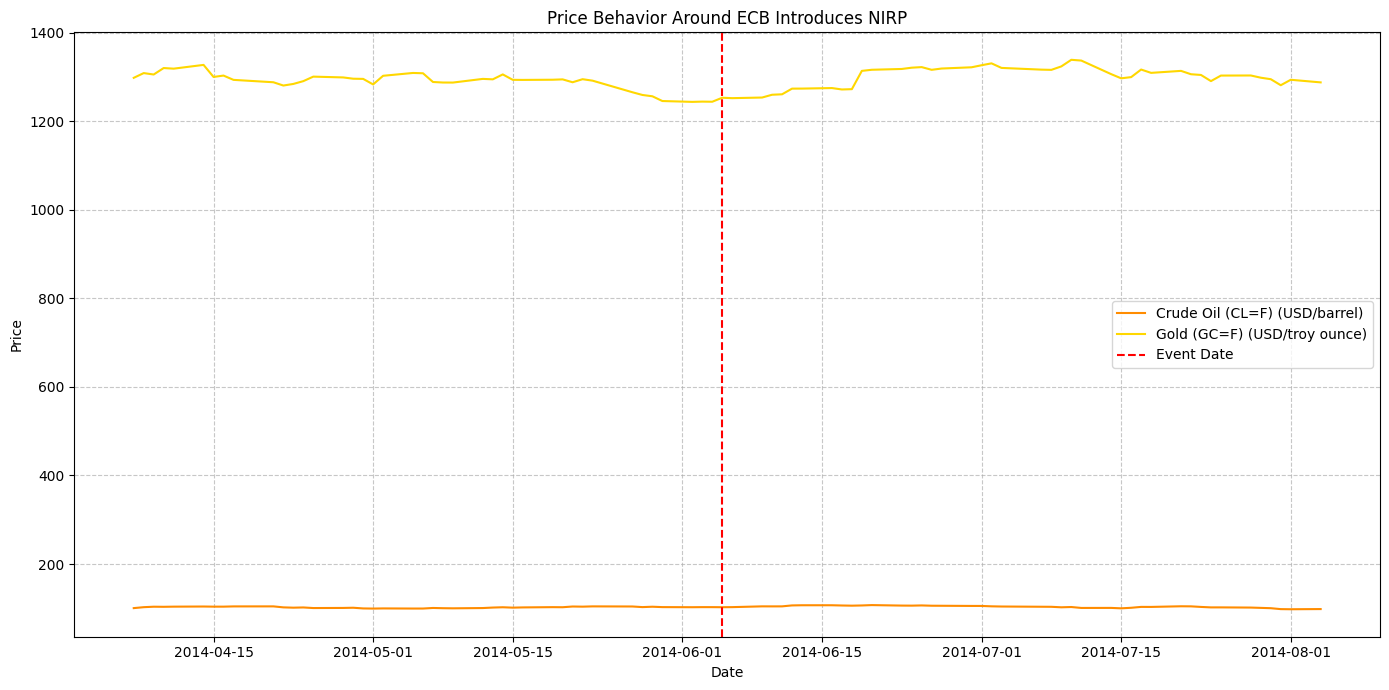

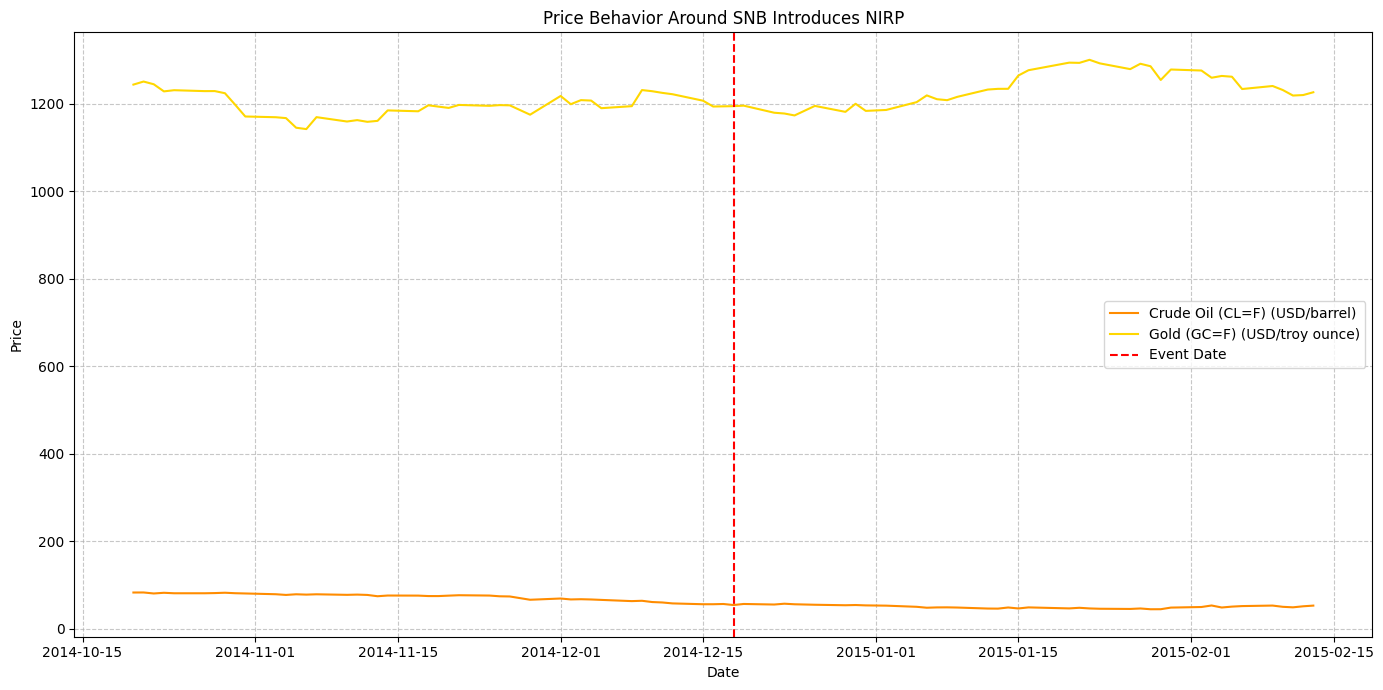

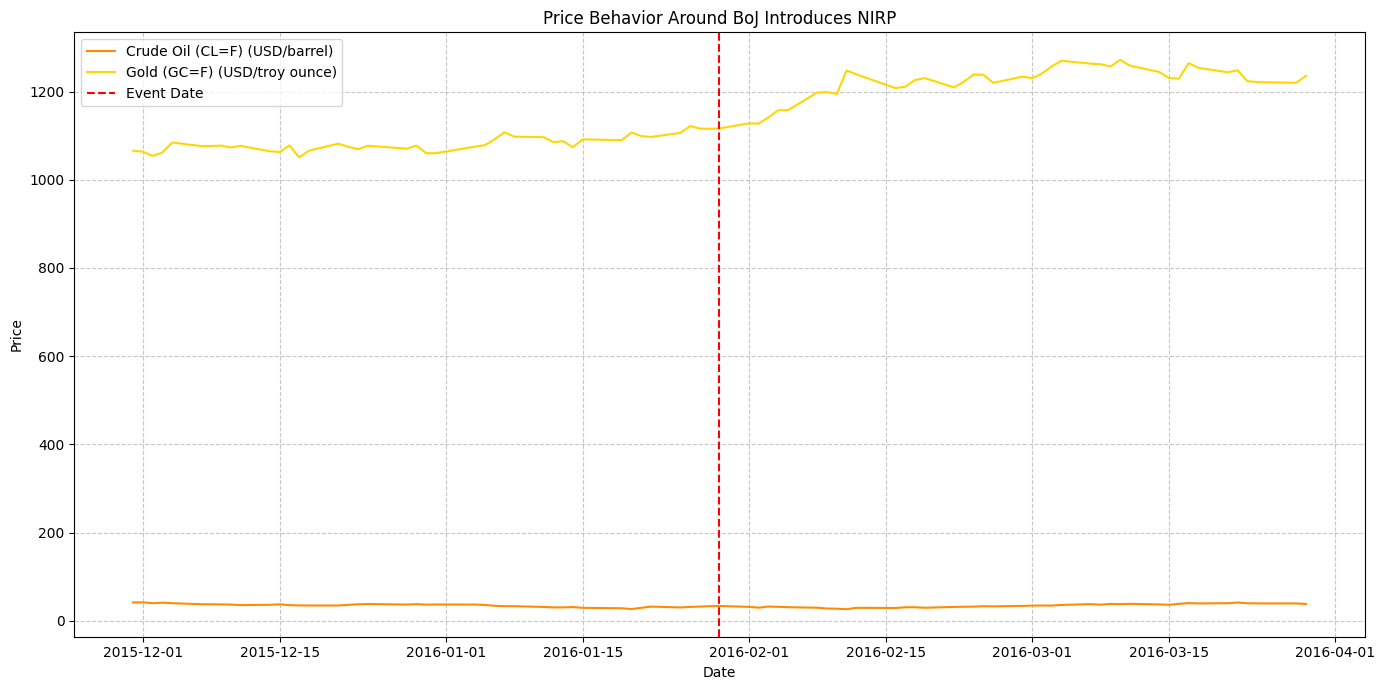

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

# Define ticker symbols for Oil and Gold futures
oil_ticker = 'CL=F'
gold_ticker = 'GC=F'

# combined_data should be available from cell abc14c11

# Define a few significant global events
# Format: {'Event Name': 'YYYY-MM-DD'}
events = {
    'Financial Crisis Peak': '2008-09-15', # Lehman Brothers collapse
    'COVID-19 Pandemic Start': '2020-03-09', # Market crash due to COVID-19 fears
    'Russia-Ukraine War Start': '2022-02-24', # Invasion of Ukraine
    'Post-2010 Inflationary Concerns': '2010-06-01', # Representative of commodity boom / inflation fears post-2008
    'Post-COVID Inflation Surge Start': '2021-03-01', # When inflation began to accelerate significantly globally
    'ECB Introduces NIRP': '2014-06-05', # European Central Bank introduces negative deposit facility rate
    'SNB Introduces NIRP': '2014-12-18', # Swiss National Bank introduces negative rates
    'BoJ Introduces NIRP': '2016-01-29'  # Bank of Japan introduces negative rates
}

# Define the window around each event (e.g., +/- 60 days)
window_days = 60

for event_name, event_date_str in events.items():
    event_date = pd.to_datetime(event_date_str)

    start_date = event_date - pd.Timedelta(days=window_days)
    end_date = event_date + pd.Timedelta(days=window_days)

    # Filter data for the event window
    event_data = combined_data.loc[start_date:end_date]

    if not event_data.empty:
        plt.figure(figsize=(14, 7))

        plt.plot(event_data.index, event_data['Oil_Close'], label=f'Crude Oil (CL=F) (USD/barrel)', color='darkorange')
        plt.plot(event_data.index, event_data['Gold_Close'], label=f'Gold (GC=F) (USD/troy ounce)', color='gold')

        plt.axvline(event_date, color='red', linestyle='--', label='Event Date')

        plt.title(f'Price Behavior Around {event_name}')
        plt.xlabel('Date')
        plt.ylabel('Price')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()
    else:
        print(f"No data available for event '{event_name}' in the specified window.")

### Autocorrelation of Oil and Gold Daily Percentage Changes

Autocorrelation measures the correlation of a time series with a lagged version of itself. It helps identify patterns such as trend, seasonality, or other non-random behaviors in the data. For financial time series like daily returns, we often look for the absence of significant autocorrelation, which suggests that returns are random and thus unpredictable from their own past values.

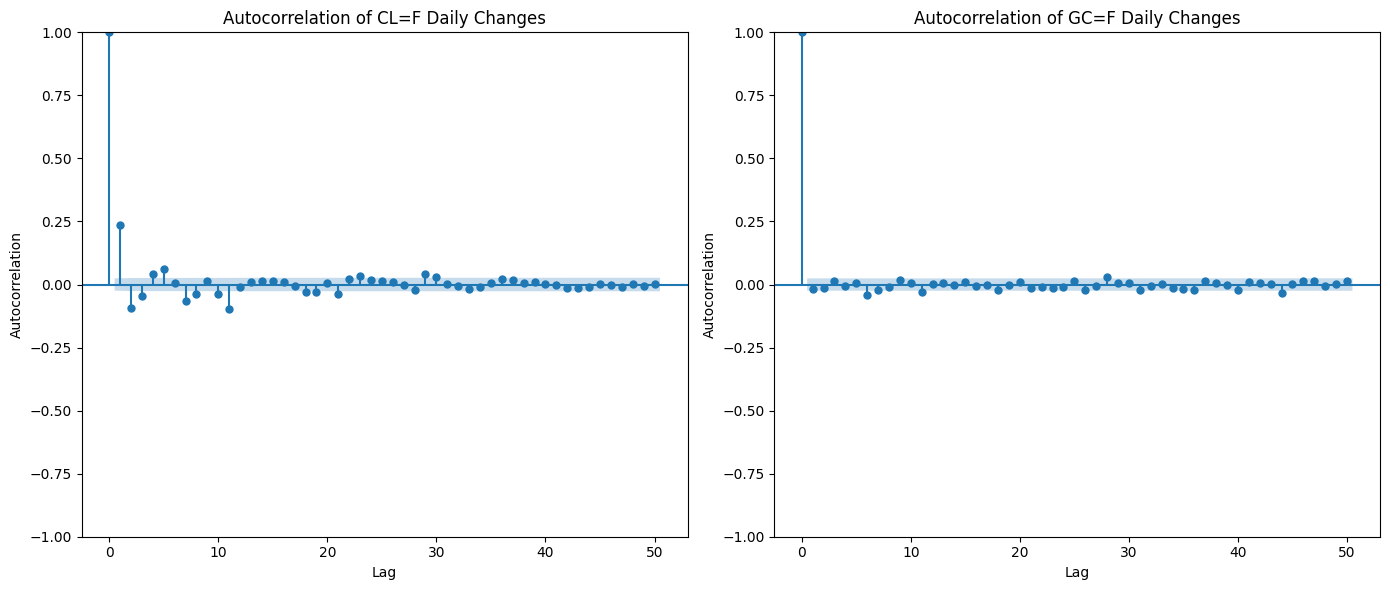

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

# Plot Autocorrelation Function (ACF) for Oil daily percentage changes
plt.figure(figsize=(14, 6))
plot_acf(price_changes['Oil_Close'], lags=50, ax=plt.subplot(121), title=f'Autocorrelation of {oil_ticker} Daily Changes')
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')

# Plot Autocorrelation Function (ACF) for Gold daily percentage changes
plot_acf(price_changes['Gold_Close'], lags=50, ax=plt.subplot(122), title=f'Autocorrelation of {gold_ticker} Daily Changes')
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')

plt.tight_layout()
plt.show()

### Interpretation of Autocorrelation Plots

*   **Y-axis**: Represents the autocorrelation coefficient (ranging from -1 to 1).
*   **X-axis**: Represents the lag, which is the number of time periods (days in this case) between the observation and the lagged observation.
*   **Blue Shaded Area**: This represents the confidence interval. Any autocorrelation values falling within this area are generally considered not statistically significant at a 95% confidence level.

For financial asset returns, we typically expect to see very little significant autocorrelation beyond lag 0. This is because if there were strong predictable patterns (high autocorrelation), they would likely be arbitraged away by market participants. If a bar extends significantly outside the blue area, it suggests that past returns (at that specific lag) have a statistically significant correlation with current returns.